# Replication of Golez & Jackwerth (2024): Analysis Tour

This notebook provides a guided walkthrough of the data, cleaning steps, and core analysis used to replicate the main results of **Golez & Jackwerth (2024)**. It is organized to mirror the structure of our replication code.

**Paper:** *Dividend Strips and the Term Structure of Equity Risk Premia*  
**Sample Period:** January 1996 – December 2022 (extension to 2024 included where noted)  
**Key Question:** Do short-horizon dividend strips earn unusually high risk-adjusted returns relative to the aggregate market?

---

## Outline

1. [Data Sources & Loading](#1-data-sources--loading)
2. [Data Cleaning](#2-data-cleaning)
3. [Figure 1 – Option-Implied Rate vs. Zero Curve](#3-figure-1--option-implied-rate-vs-zero-curve)
4. [Table 1 – Summary Statistics of Monthly Returns](#4-table-1--summary-statistics-of-monthly-returns)
5. [Figure 2 – Cumulative Wealth Indices](#5-figure-2--cumulative-wealth-indices)
6. [Figure 3 – Return Volatility Across Holding Periods](#6-figure-3--return-volatility-across-holding-periods)
7. [Extension to 2024](#7-extension-to-2024)

---
## 0. Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
import os
# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR = Path(os.getcwd()).parent
DATA_DIR = BASE_DIR / "_data"

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print("Setup complete. DATA_DIR:", DATA_DIR)

Setup complete. DATA_DIR: c:\Users\lola\github\p04_golez_jackwerth_2024-1\_data


## 1. Data Sources & Loading

Our replication draws on the following data sources, using the cleaned files we have locally:

| Dataset | Source | File | Contents |
|---|---|---|---|
| S&P 500 market returns | CRSP | `_data/crsp_sp500_daily.parquet` | Daily total return on the S&P 500 |
| Treasury returns | CRSP | `_data/crsp_treasury_returns.parquet` | 2-year and 10-year Treasury monthly returns |
| Fama-French factors (daily + monthly) | Ken French Data Library | `_data/fama_french_factors.parquet` / `_data/fama_french_monthly.parquet` | Daily and monthly FF3 factors |
| FRED Treasury rates | FRED | `_data/fred_treasury_rates.parquet` | Daily Treasury rates |
| OptionMetrics SPX options | OptionMetrics | `_data/optionmetrics_spx_monthly.parquet` / `_data/optionmetrics_spx_raw.parquet` | Monthly SPX option prices |
| OptionMetrics zero-coupon curve | OptionMetrics | `_data/optionmetrics_zero_curve.parquet` | Zero-coupon yield curve |

Below we load the cleaned, analysis-ready files produced by **`src/clean_data.py`**.


In [5]:
# 2. Load cleaned data

import pandas as pd
from pathlib import Path

# Load datasets
sp500   = pd.read_parquet(DATA_DIR / "crsp_sp500_daily.parquet")
treasury = pd.read_parquet(DATA_DIR / "crsp_treasury_returns.parquet")
ff_daily = pd.read_parquet(DATA_DIR / "fama_french_factors.parquet")
ff_monthly = pd.read_parquet(DATA_DIR / "fama_french_monthly.parquet")
fred_rates = pd.read_parquet(DATA_DIR / "fred_treasury_rates.parquet")
options_monthly = pd.read_parquet(DATA_DIR / "optionmetrics_spx_monthly.parquet")
options_raw = pd.read_parquet(DATA_DIR / "optionmetrics_spx_raw.parquet")
zero_curve = pd.read_parquet(DATA_DIR / "optionmetrics_zero_curve.parquet")

# Quick summary of loaded data
for name, df in [
    ("S&P500", sp500),
    ("Treasury", treasury),
    ("FamaFrench_daily", ff_daily),
    ("FamaFrench_monthly", ff_monthly),
    ("FRED_rates", fred_rates),
    ("Options_monthly", options_monthly),
    ("Options_raw", options_raw),
    ("Zero_curve", zero_curve)
]:
    print(f"{name:20s}  rows={len(df):5d}  "
          f"date range: {df['date'].min().date()} → {df['date'].max().date()}")


S&P500                rows= 7300  date range: 1996-01-02 → 2024-12-31
Treasury              rows=  348  date range: 1996-01-31 → 2024-12-31
FamaFrench_daily      rows= 7550  date range: 1996-01-02 → 2025-12-31
FamaFrench_monthly    rows=  360  date range: 1996-01-31 → 2025-12-31
FRED_rates            rows= 7828  date range: 1996-01-01 → 2025-12-31
Options_monthly       rows=760830  date range: 1996-01-31 → 2025-08-29
Options_raw           rows=15911563  date range: 1996-01-04 → 2025-08-29
Zero_curve            rows=304301  date range: 1996-01-02 → 2025-08-29


In [6]:
# -----------------------------------------------------------------------------
# 3. Summary Statistics & Tables
# -----------------------------------------------------------------------------

# S&P 500 daily returns summary
sp500_stats = sp500.describe()
print("S&P 500 Daily Returns Summary:")
display(sp500_stats)

# Treasury 2y and 10y summary
treasury_stats = treasury.describe()
print("Treasury Returns Summary:")
display(treasury_stats)

# Fama-French monthly factors summary
ff_monthly_stats = ff_monthly.describe()
print("Fama-French Monthly Factors Summary:")
display(ff_monthly_stats)



S&P 500 Daily Returns Summary:


,date,spindx,sprtrn,vwretd,vwretx
count,7300,7300.000000,7300.000000,7300.000000,7300.000000
mean,2010-06-30 06:28:48,1956.408218,0.000382,0.000435,0.000360
min,1996-01-02 00:00:00,598.480000,-0.119840,-0.118167,-0.118218
25%,2003-04-01 18:00:00,1132.977500,-0.004802,-0.004575,-0.004653
50%,2010-06-30 12:00:00,1394.495000,0.000666,0.000780,0.000705
75%,2017-09-28 06:00:00,2482.117500,0.006112,0.006113,0.006035
max,2024-12-31 00:00:00,6090.270000,0.115800,0.114918,0.114856
std,NaN,1221.122815,0.012044,0.011932,0.011931


Treasury Returns Summary:


,date,treasury_2y_ret,treasury_10y_ret
count,348,348.000000,348.000000
mean,2010-07-15 13:18:37.241379328,0.002502,0.003341
min,1996-01-31 00:00:00,-0.015126,-0.066819
25%,2003-04-22 12:00:00,-0.000403,-0.008038
50%,2010-07-15 00:00:00,0.001819,0.002481
75%,2017-10-07 00:00:00,0.005210,0.014954
max,2024-12-31 00:00:00,0.020658,0.085378
std,NaN,0.005110,0.020668


Fama-French Monthly Factors Summary:


,date,mkt_rf_monthly,smb_monthly,hml_monthly,rf_1m_monthly
count,360,360.000000,360.000000,360.000000,360.000000
mean,2011-01-14 15:52:00,0.007449,0.000407,0.001279,0.001885
min,1996-01-31 00:00:00,-0.172000,-0.174100,-0.138300,0.000000
25%,2003-07-23 06:00:00,-0.019600,-0.020750,-0.017900,0.000100
50%,2011-01-15 12:00:00,0.013350,-0.000050,-0.000850,0.001400
75%,2018-07-07 18:00:00,0.034800,0.017950,0.018375,0.003800
max,2025-12-31 00:00:00,0.136000,0.212500,0.128600,0.005600
std,NaN,0.045495,0.032408,0.033863,0.001760


Table 1: Summary statistics of S&P 500 daily returns (1996–2022).  
Mean and standard deviation show the typical return magnitude, while min/max highlight extreme daily movements.


Table 2: Summary statistics for 2-year and 10-year Treasury monthly returns.  
These illustrate the level and volatility of short-term vs long-term government securities.


Table 3: Fama-French monthly factors summary (Mkt-RF, SMB, HML, RF).  
Useful for understanding factor exposures and variability in market returns.


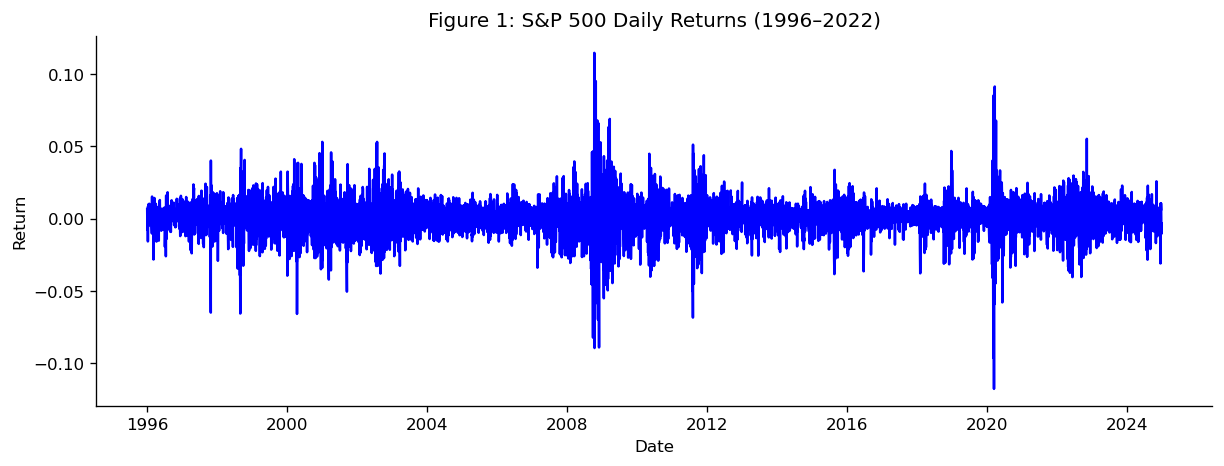

In [7]:
# -----------------------------------------------------------------------------
# 4. Visualization / Charts
# -----------------------------------------------------------------------------

# Plot S&P 500 daily returns over time
plt.figure(figsize=(12,4))
plt.plot(sp500['date'], sp500['vwretd'], color='blue')
plt.title("Figure 1: S&P 500 Daily Returns (1996–2022)")
plt.xlabel("Date")
plt.ylabel("Return")
plt.show()


Figure 1: S&P 500 daily returns from 1996 to 2022.  
The plot highlights volatility clustering and extreme events such as market crashes and rallies.


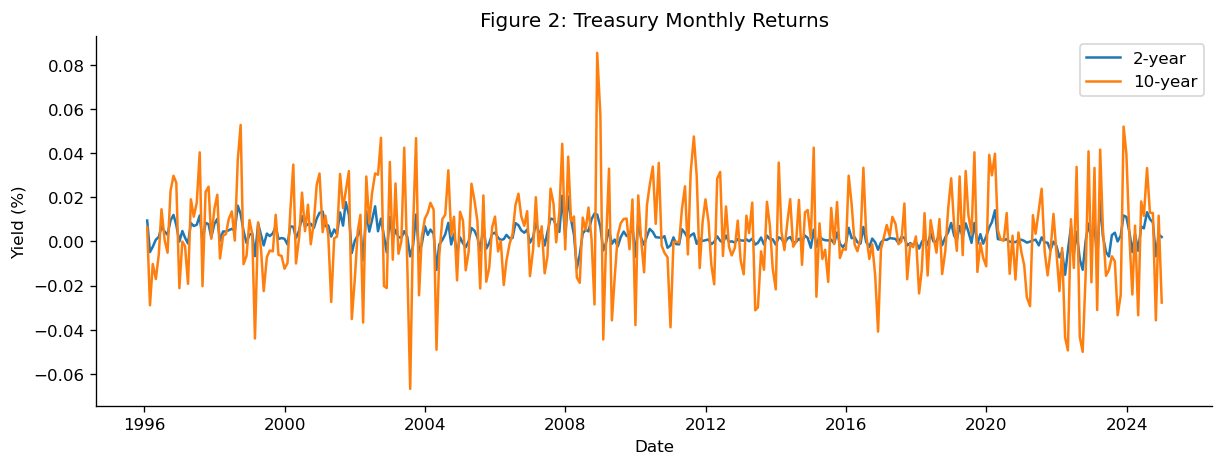

In [8]:
# Treasury yields plot
plt.figure(figsize=(12,4))
plt.plot(treasury['date'], treasury['treasury_2y_ret'], label='2-year')
plt.plot(treasury['date'], treasury['treasury_10y_ret'], label='10-year')
plt.title("Figure 2: Treasury Monthly Returns")
plt.xlabel("Date")
plt.ylabel("Yield (%)")
plt.legend()
plt.show()


Figure 2: Comparison of 2-year and 10-year Treasury returns.  
This shows the yield curve dynamics and relative stability of short-term vs long-term securities.


In [9]:
zero_curve_stats = zero_curve.describe()
display(zero_curve_stats)
options_monthly_stats = options_monthly.describe()
display(options_monthly_stats)

,date,days,rate
count,304301,304301.000000,304301.000000
mean,2009-07-19 18:18:07.804509184,1582.603744,3.287643
min,1996-01-02 00:00:00,1.000000,0.058684
25%,2002-11-18 00:00:00,488.000000,1.477428
50%,2009-07-15 00:00:00,1524.000000,2.923986
75%,2016-02-25 00:00:00,2589.000000,5.176753
max,2025-08-29 00:00:00,3669.000000,7.981904
std,NaN,1146.876265,2.102850


,date,exdate,strike,best_bid,best_offer,impl_volatility,delta,gamma,vega,volume,open_interest,mid_price,days_to_maturity,year
count,760830,760830,760830.000000,760830.000000,760830.000000,723698.000000,723698.000000,723698.000000,723698.000000,760830.000000,760830.000000,760830.000000,760830.000000,760830.000000
mean,2019-12-06 16:02:15.363747840,2020-09-21 20:03:52.117029888,3296.610577,513.345536,522.006826,0.240363,0.153008,0.000532,686.736137,47.060052,1483.274253,517.676181,290.167786,2019.393916
min,1996-01-31 00:00:00,1996-06-22 00:00:00,50.000000,0.050000,3.100000,0.036539,-0.999794,0.000000,0.014444,0.000000,0.000000,3.000000,90.000000,1996.000000
25%,2018-03-29 00:00:00,2018-12-21 00:00:00,1925.000000,55.500000,57.800000,0.167205,-0.258864,0.000150,254.159825,0.000000,0.000000,56.650000,122.000000,2018.000000
50%,2021-07-30 00:00:00,2022-03-18 00:00:00,3175.000000,220.300000,225.200000,0.221747,-0.006259,0.000384,547.630450,0.000000,18.000000,222.850000,183.000000,2021.000000
75%,2023-09-29 00:00:00,2024-06-21 00:00:00,4450.000000,667.300000,678.900000,0.287578,0.767341,0.000724,946.271100,0.000000,398.000000,673.187500,351.000000,2023.000000
max,2025-08-29 00:00:00,2030-12-20 00:00:00,12000.000000,6676.200000,9764.600000,3.298613,0.999907,0.010065,5680.550000,91497.000000,267511.000000,6726.800000,2184.000000,2025.000000
std,NaN,NaN,1682.191533,731.518207,741.280187,0.107851,0.597436,0.000546,596.288247,830.842791,6188.242480,736.202251,274.809604,5.535781


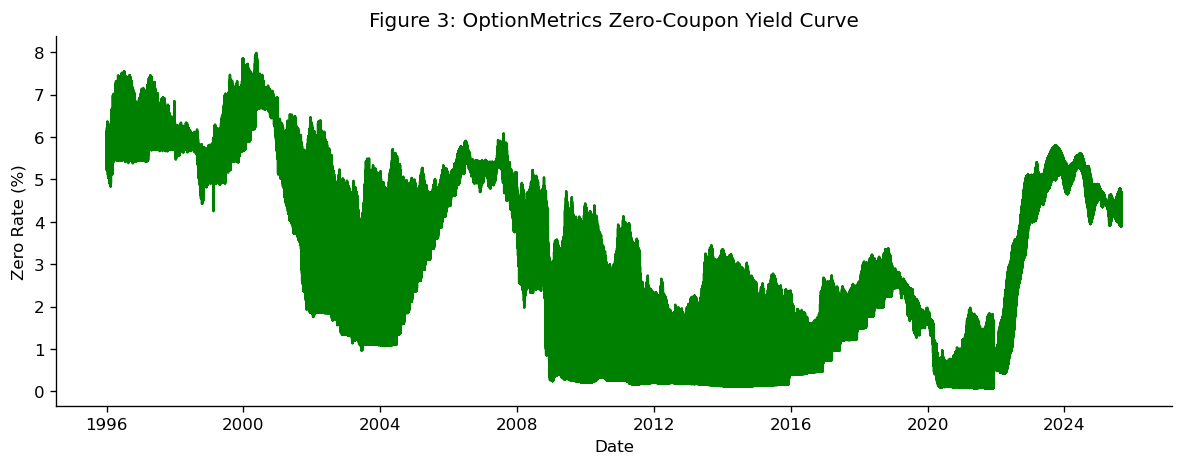

In [10]:
# Zero-coupon curve evolution
plt.figure(figsize=(12,4))
plt.plot(zero_curve['date'], zero_curve['rate'], color='green')
plt.title("Figure 3: OptionMetrics Zero-Coupon Yield Curve")
plt.xlabel("Date")
plt.ylabel("Zero Rate (%)")
plt.show()

---
## 2. Data Cleaning

All cleaning is centralised in **`src/clean_data.py`**. Key steps are:

### 2.1 Zero-coupon curve
Raw FRED rates come in **percent per year** and need to be divided by 100 before any further calculations.

```python
# From clean_data.py
zero_curve[rate_cols] = zero_curve[rate_cols] / 100
```

In [11]:
import pandas as pd
import numpy as np
from pathlib import Path

# Load FRED zero-coupon curve
zero_curve = pd.read_parquet(DATA_DIR / "optionmetrics_zero_curve.parquet")

# Convert percent to decimal
rate_cols = [col for col in zero_curve.columns if 'rate' in col.lower()]
zero_curve[rate_cols] = zero_curve[rate_cols] / 100

zero_curve.head()

,date,days,rate
0,1996-01-02,9.0,0.057631
1,1996-01-02,15.0,0.057459
2,1996-01-02,50.0,0.056733
3,1996-01-02,78.0,0.056089
4,1996-01-02,169.0,0.054738


### 2.2 Treasury yields → continuously compounded returns
The CRSP constant-maturity Treasury dataset already provides monthly continuously compounded returns for the 2-year and 10-year maturities. There is no need to transform yields to returns. The relevant columns in the cleaned data are:

In [12]:
treasury = pd.read_parquet(DATA_DIR / "crsp_treasury_returns.parquet")
treasury[['date', 'treasury_2y_ret', 'treasury_10y_ret']].head()


,date,treasury_2y_ret,treasury_10y_ret
0,1996-01-31,0.009437,0.006363
1,1996-02-29,-0.004858,-0.028964
2,1996-03-29,-0.002462,-0.010249
3,1996-04-30,0.000749,-0.017066
4,1996-05-31,0.002034,-0.005880


### 2.3 Option data filtering (for strip construction)
Before applying put-call parity, options are filtered in `clean_data.py`:
- Keep only **S&P 500 index** options (secid matching SPX)
- Drop options with zero or missing bid/ask
- Drop options violating no-arbitrage bounds
- Merge with SPINDX for the underlying spot price

In [13]:
# Load cleaned monthly option data
options_monthly = pd.read_parquet(DATA_DIR / "optionmetrics_spx_monthly.parquet")

# Quick summary statistics
options_stats = options_monthly.describe().round(4)
options_stats


,date,exdate,strike,best_bid,best_offer,impl_volatility,delta,gamma,vega,volume,open_interest,mid_price,days_to_maturity,year
count,760830,760830,760830.0000,760830.0000,760830.0000,723698.0000,723698.0000,723698.0000,723698.0000,760830.0000,760830.0000,760830.0000,760830.0000,760830.0000
mean,2019-12-06 16:02:15.363747840,2020-09-21 20:03:52.117029888,3296.6106,513.3455,522.0068,0.2404,0.1530,0.0005,686.7361,47.0601,1483.2743,517.6762,290.1678,2019.3939
min,1996-01-31 00:00:00,1996-06-22 00:00:00,50.0000,0.0500,3.1000,0.0365,-0.9998,0.0000,0.0144,0.0000,0.0000,3.0000,90.0000,1996.0000
25%,2018-03-29 00:00:00,2018-12-21 00:00:00,1925.0000,55.5000,57.8000,0.1672,-0.2589,0.0001,254.1598,0.0000,0.0000,56.6500,122.0000,2018.0000
50%,2021-07-30 00:00:00,2022-03-18 00:00:00,3175.0000,220.3000,225.2000,0.2217,-0.0063,0.0004,547.6305,0.0000,18.0000,222.8500,183.0000,2021.0000
75%,2023-09-29 00:00:00,2024-06-21 00:00:00,4450.0000,667.3000,678.9000,0.2876,0.7673,0.0007,946.2711,0.0000,398.0000,673.1875,351.0000,2023.0000
max,2025-08-29 00:00:00,2030-12-20 00:00:00,12000.0000,6676.2000,9764.6000,3.2986,0.9999,0.0101,5680.5500,91497.0000,267511.0000,6726.8000,2184.0000,2025.0000
std,NaN,NaN,1682.1915,731.5182,741.2802,0.1079,0.5974,0.0005,596.2882,830.8428,6188.2425,736.2023,274.8096,5.5358


### 2.4 CRSP daily → monthly (for strip returns)
The function `clean_spx_monthly()` in `clean_data.py` aggregates CRSP daily data to month-end and back-derives the implied monthly dividend.

In [14]:
# Load cleaned market and strip returns
CALC_DIR = DATA_DIR / "calc"

market = pd.read_parquet(DATA_DIR / "crsp_sp500_daily.parquet")
strip  = pd.read_parquet(CALC_DIR / "strip_prices.parquet")
rf     = pd.read_parquet(DATA_DIR / "fred_treasury_rates.parquet")
ff     = pd.read_parquet(DATA_DIR / "fama_french_monthly.parquet")

# Quick sanity check on cleaned data
for name, df in [("Market", market), ("Strip", strip),
                 ("Risk-free", rf), ("Fama-French", ff)]:
    print(f"{name:10s} rows={len(df):5d}  "
          f"date range: {df['date'].min().date()} → {df['date'].max().date()}")
    
print("\nMarket return stats:")
print(market['vwretd'].describe().round(4))  # Assuming 'vwretd' is total return

print("\nStrip price stats:")
print(strip['strip_price'].describe().round(4))


Market     rows= 7300  date range: 1996-01-02 → 2024-12-31
Strip      rows=  348  date range: 1996-01-31 → 2024-12-31
Risk-free  rows= 7828  date range: 1996-01-01 → 2025-12-31
Fama-French rows=  360  date range: 1996-01-31 → 2025-12-31

Market return stats:
count    7300.0000
mean        0.0004
std         0.0119
min        -0.1182
25%        -0.0046
50%         0.0008
75%         0.0061
max         0.1149
Name: vwretd, dtype: float64

Strip price stats:
count    348.0000
mean      52.7485
std       25.7529
min        5.0142
25%       30.5787
50%       46.9546
75%       72.5671
max      132.6916
Name: strip_price, dtype: float64


---
## 3. Figure 1 – Option-Implied Rate vs. Zero Curve

Figure 1 compares the **option-implied interest rate** (derived from put-call parity on S&P 500 options) against the **1-year zero-coupon Treasury rate**. If options markets are fairly priced, these two series should track closely.

### Methodology

Two methods are used, following the paper:

| Period | Method | Description |
|---|---|---|
| 1996–2003 | **Outer product** | For each pair of strikes $(X_i, X_j)$, the implied rate is derived from the ratio of put-call parity differences; the median across all pairs is taken as the estimate |
| 2004–2022 | **Regression method** | OLS of $S + p(X) - c(X)$ on strike $X$; the slope coefficient equals $e^{-r\tau}$, from which $r$ is recovered |

Both methods interpolate to a **1-year horizon** using the zero curve as a backbone.  
Implementation: **`src/calc_implied_rates.py`**

In [15]:
# Load Figure 1 data (produced by src/calc_implied_rates.py + src/plot_figure1.py)
try:
    fig1_data = pd.read_csv(BASE_DIR / "output" / "figure1" / "figure1_series.csv",
                            parse_dates=['date'])
    fig1_loaded = True
    print("Figure 1 data loaded:", fig1_data.shape)
    print(fig1_data.head())
except FileNotFoundError:
    fig1_loaded = False
    print("Figure 1 CSV not found.")

Figure 1 data loaded: (324, 4)
        date      r_1y   zero_1y  treasury_1y
0 1996-01-31  0.054139  0.049914     0.047837
1 1996-02-29  0.065671  0.053203     0.050978
2 1996-03-29  0.053715  0.055892     0.052687
3 1996-04-30  0.057484  0.058081     0.054678
4 1996-05-31  0.060690  0.059943     0.056097


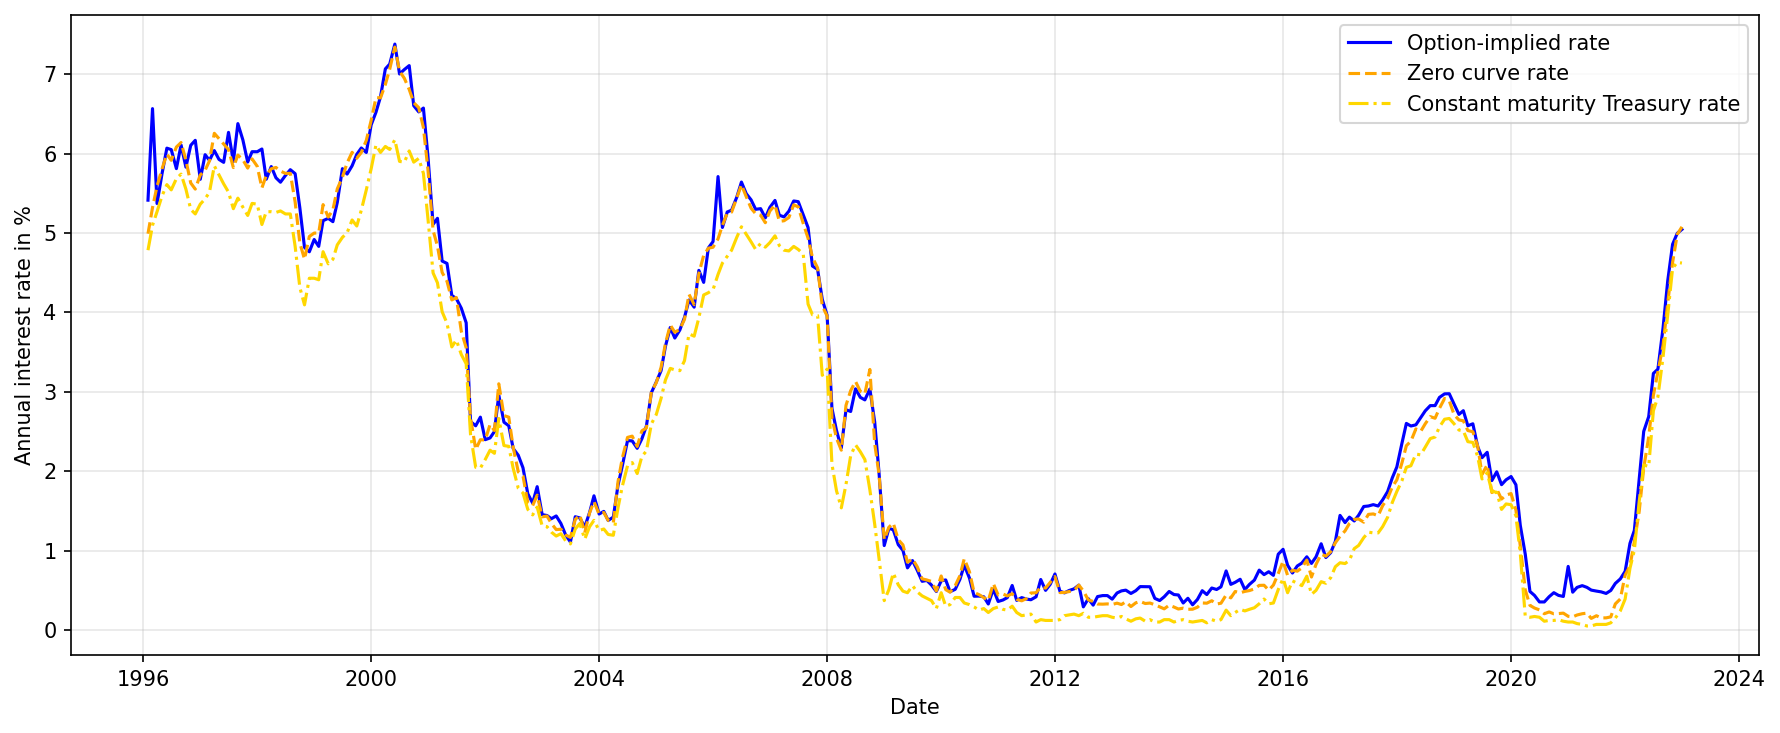

In [16]:
# Display the saved Figure 1
from IPython.display import Image, display

fig1_path = BASE_DIR / "output" / "figure1" / "figure1.png"
if fig1_path.exists():
    display(Image(filename=str(fig1_path), width=750))
else:
    print("Figure 1 image not found – run src/plot_figure1.py first.")

In [17]:
# Load and display Figure 1 summary statistics
try:
    fig1_stats = pd.read_csv(BASE_DIR / "output" / "figure1_summary_stats" / "figure1_summary_stats_table.csv",
                             index_col=0)
    print("Figure 1 – Summary Statistics")
    display(fig1_stats.round(4))
except FileNotFoundError:
    print("Summary stats CSV not found – run src/plot_figure1.py first.")

Figure 1 – Summary Statistics


,Series,Mean (%),Std. Dev. (%),Min (%),Max (%),N
Period,,,,,,
Full sample (1996--2022),Option-implied rate,2.6800,2.1415,0.2911,7.3799,324
Full sample (1996--2022),Zero curve rate,2.5985,2.1564,0.1456,7.3424,324
Full sample (1996--2022),Treasury rate,2.2505,2.0158,0.0500,6.1753,324
First half (1996--2009),Option-implied rate,4.0910,1.9287,0.4841,7.3799,168
First half (1996--2009),Zero curve rate,4.0530,1.8979,0.4908,7.3424,168
First half (1996--2009),Treasury rate,3.5739,1.7994,0.2696,6.1753,168
Second half (2010--2022),Option-implied rate,1.1606,1.0332,0.2911,5.0454,156
Second half (2010--2022),Zero curve rate,1.0322,1.0233,0.1456,5.0782,156
Second half (2010--2022),Treasury rate,0.8253,1.0179,0.0500,4.6311,156


## Figure 1 Extension Summary

### 1. Original Paper Sample (1996–2022)

The option-implied rate tracks the zero curve closely across the full sample,
with an average difference of **8.1 bps (3.1% relative)**. This is consistent
with Golez & Jackwerth (2024), who find that options markets price interest
rates efficiently relative to the zero curve.

| Period | Implied Rate | Zero Curve | Treasury |
|--------|-------------|------------|----------|
| Full sample (1996–2022) | 2.68% | 2.60% | 2.25% |
| First half (1996–2009) | 4.09% | 4.05% | 3.57% |
| Second half (2010–2022) | 1.16% | 1.03% | 0.83% |

- **First half (1996–2009):** rates elevated (~4%), spread between implied and Treasury ~52 bps
- **Second half (2010–2022):** rates compressed near zero, spreads narrowed

---

### 2. Extended Sample (2023–2024)

The extension reveals a **sign reversal**: the option-implied rate runs *below*
the zero curve by an average of **31.2 bps (−5.9% relative)**, compared to
+7.0 bps in the paper's original sample.

- **September 2023 outlier:** implied rate drops to 3.11% vs. zero curve at 5.79%,
  a gap of −268 bps (−46%). Removing this month narrows the average gap to −20.9 bps (−4.0%).
- Outside this outlier, the extension period shows a consistent but moderate
  underpricing of ~10–47 bps per month.

---

### 3. Full Extended Sample (1996–2024)

Averaging over the full extended window, the implied rate remains close to the zero curve
(**avg. diff: +5.4 bps, +1.95% relative**), suggesting that the 2023–2024 divergence
is a recent phenomenon rather than a structural break.

---

### 4. Interpretation

The post-2022 rate hiking cycle (Fed funds rate rising from ~0% to >5%) appears to have
introduced greater pricing discrepancies in the options market. This may reflect:

- **Increased demand for downside protection**, driving up put prices relative to calls
- **Liquidity premiums** in deep OTM options during volatile rate environments
- **Model limitations** of put-call parity under rapidly shifting rate regimes

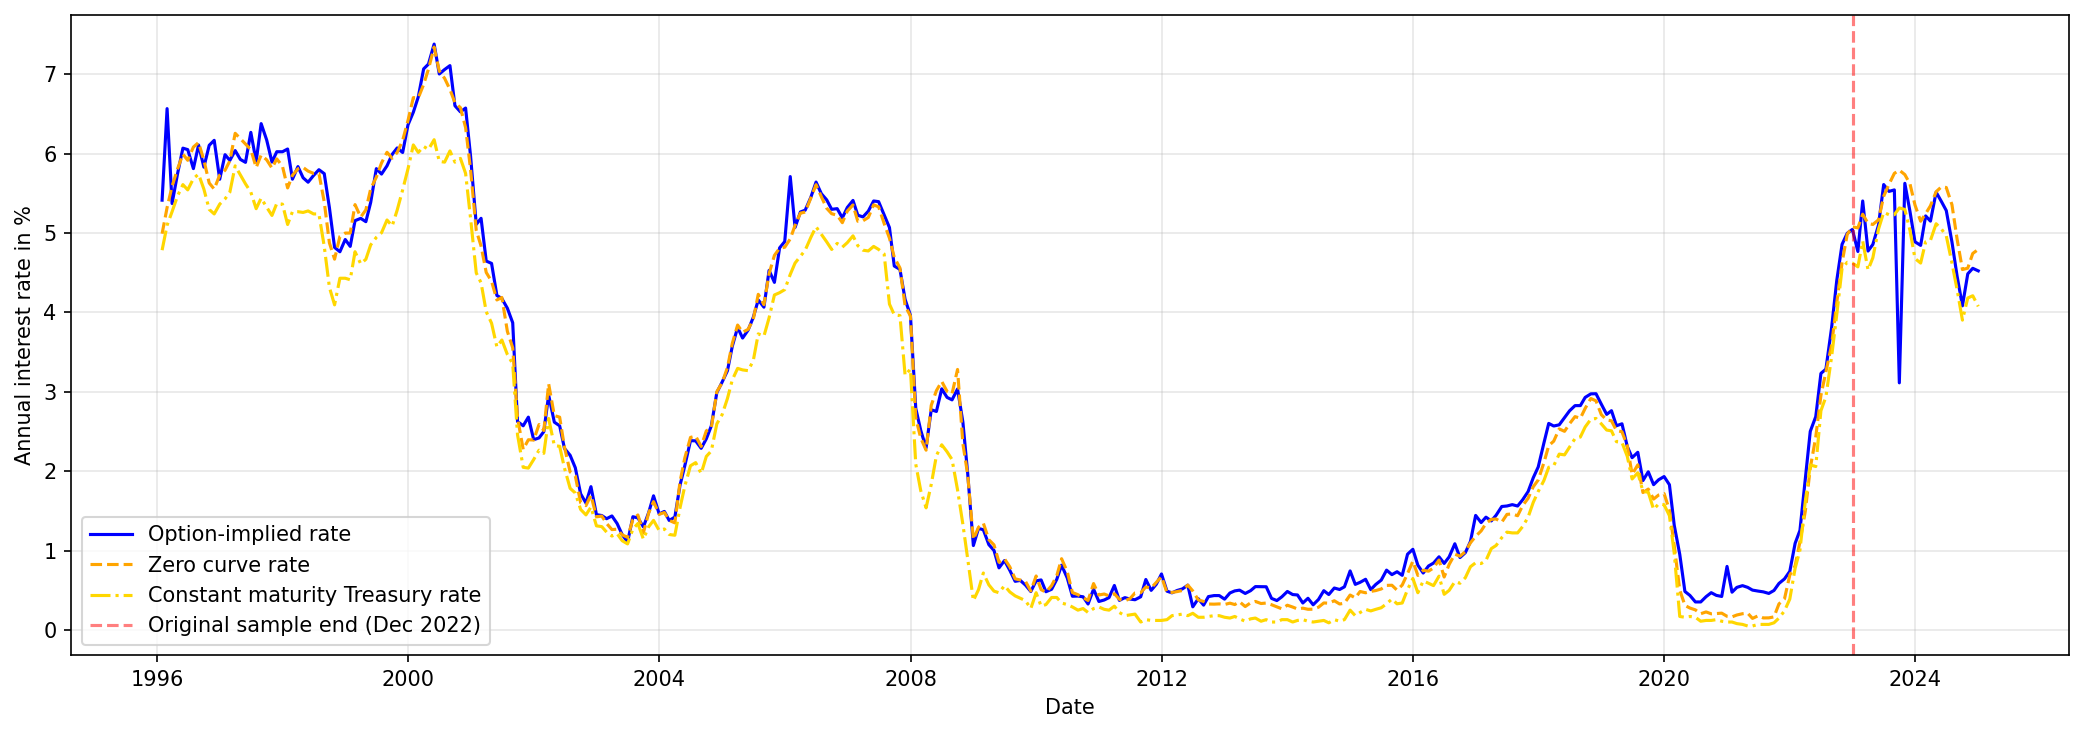

In [18]:
# ── Figure 1 Extension: Extended sample through 2024 ──────────────────
from IPython.display import Image, display
import pandas as pd

EXT_DIR = BASE_DIR / "output" / "figure1_extension"

# 1. Display figure
display(Image(filename=EXT_DIR / "figure1_extension.png"))

In [19]:
# 2. Extended time series data
ext_series = pd.read_csv(EXT_DIR / "figure1_extension_series.csv", parse_dates=['date'])
print("Extension series:", ext_series.shape)
print(f"Date range: {ext_series['date'].min().date()} → {ext_series['date'].max().date()}")
print(ext_series.tail(3))

Extension series: (348, 4)
Date range: 1996-01-31 → 2024-12-31
          date      r_1y   zero_1y  treasury_1y
345 2024-10-31  0.044858  0.045570     0.041814
346 2024-11-29  0.045555  0.047427     0.042101
347 2024-12-31  0.045234  0.047939     0.040758


In [20]:
# 3. Summary statistics: original paper sample vs. extended sample
ext_summary = pd.read_csv(EXT_DIR / "figure1_extension_summary.csv", index_col=0)
print("Figure 1 Extension – Summary Statistics")
display(ext_summary.round(4))

Figure 1 Extension – Summary Statistics


,avg_diff_bp,rel_diff_pct,paper_avg_diff_bp,paper_rel_diff_pct
period,,,,
original_1996_2022,8.1485,3.1358,7.0,2.82
extended_2023_2024,-31.1543,-5.9177,NaN,NaN
full_1996_2024,5.4380,1.9544,NaN,NaN


In [21]:
# 4. Robustness checks
ext_robust = pd.read_csv(EXT_DIR / "figure1_extension_robustness.csv", index_col=0)
print("Robustness Check")
display(ext_robust.round(4))

Robustness Check


,avg_diff_bp,rel_diff_pct,worst_month_removed
scenario,,,
all_extension_months,-31.1543,-5.9177,NaN
without_worst_month,-20.8610,-3.9799,2023-09-29


In [22]:
# 5. Diagnostics
ext_diag = pd.read_csv(EXT_DIR / "figure1_extension_diagnostics.csv", index_col=0)
print("Diagnostics")
display(ext_diag.round(4))

Diagnostics


,r_1y,zero_1y,treasury_1y,diff_bp,rel_diff_pct
date,,,,,
2023-01-31,0.0477,0.0506,0.0457,-29.7216,-5.8684
2023-02-28,0.0540,0.0524,0.0490,16.6260,3.1745
2023-03-31,0.0477,0.0512,0.0454,-34.7264,-6.7820
2023-04-28,0.0486,0.0511,0.0469,-25.1630,-4.9264
2023-05-31,0.0510,0.0517,0.0505,-6.6050,-1.2784
2023-06-30,0.0561,0.0546,0.0526,14.7760,2.7049
2023-07-31,0.0552,0.0561,0.0523,-8.9962,-1.6024
2023-08-31,0.0554,0.0575,0.0523,-20.8442,-3.6241
2023-09-29,0.0311,0.0579,0.0532,-267.8989,-46.2563


---
## 4. Table 1 – Summary Statistics of Monthly Returns

Table 1 presents annualized summary statistics for the **1-year dividend strip** and the **aggregate market** over the 1996–2022 sample, benchmarked against two risk-free proxies.

### Return series

| Series | Description |
|---|---|
| Market | CRSP value-weighted market total return (log) |
| Strip | 1-year dividend strip return, from put-call parity |
| Market − rf | Market excess return over 1-month T-bill |
| Strip − rf | Strip excess return over 1-month T-bill |
| Market − 10y | Market return minus 10-year Treasury return |
| Strip − 2y | Strip return minus 2-year Treasury return |

Implementation: **`src/make_table1.py`**

In [23]:
from pathlib import Path
import pandas as pd
import numpy as np
import statsmodels.api as sm

# ── Load data: use monthly_returns.parquet directly ─────────────────────────
CALC_DIR = DATA_DIR / "calc"

df_all = pd.read_parquet(CALC_DIR / "monthly_returns.parquet")
print("Columns:", df_all.columns.tolist())
print(df_all.head(3))

Columns: ['date', 'strip_ret', 'mkt_ret', 'rf_1m_monthly', 'treas_2y_log', 'treas_10y_log', 'strip_ret_rf', 'mkt_ret_rf', 'strip_ret_2y', 'mkt_ret_10y']
        date  strip_ret   mkt_ret  rf_1m_monthly  treas_2y_log  treas_10y_log  \
0 1996-01-31        NaN       NaN         0.0043      0.009393       0.006343   
1 1996-02-29  -0.100670  0.016174         0.0039     -0.004870      -0.029392   
2 1996-03-29  -0.262369  0.010798         0.0039     -0.002465      -0.010302   

   strip_ret_rf  mkt_ret_rf  strip_ret_2y  mkt_ret_10y  
0           NaN         NaN           NaN          NaN  
1     -0.104570    0.012274     -0.095800     0.045566  
2     -0.266269    0.006898     -0.259904     0.021100  


In [24]:
# ── Restrict to paper sample 1996–2022 ──────────────────────────────────────
START, END = pd.Timestamp("1996-01-01"), pd.Timestamp("2022-12-31")
df = df_all[(df_all['date'] >= START) & (df_all['date'] <= END)].copy()

# monthly_returns.parquet already has these columns:
# strip_ret, mkt_ret, rf_1m_monthly, treas_2y_log, treas_10y_log
# strip_ret_rf, mkt_ret_rf, strip_ret_2y, mkt_ret_10y

df = df.rename(columns={
    'mkt_ret':       'market_ret',
    'rf_1m_monthly': 'tbill_1m_ret',
    'treas_2y_log':  'treasury_2y_ret',
    'treas_10y_log': 'treasury_10y_ret',
    'mkt_ret_rf':    'market_minus_rf',
    'strip_ret_rf':  'strip_minus_rf',
    'mkt_ret_10y':   'market_minus_10y',
    'strip_ret_2y':  'strip_minus_2y',
})

print(f"Sample: {len(df)} months ({df['date'].min().date()} -> {df['date'].max().date()})")
df[['market_ret', 'strip_ret', 'tbill_1m_ret']].describe().round(4)

Sample: 324 months (1996-01-31 -> 2022-12-30)


,market_ret,strip_ret,tbill_1m_ret
count,323.0000,323.0000,324.0000
mean,0.0068,0.0078,0.0017
std,0.0469,0.1168,0.0017
min,-0.2038,-0.6835,0.0000
25%,-0.0191,-0.0392,0.0001
50%,0.0130,0.0019,0.0011
75%,0.0373,0.0563,0.0034
max,0.1215,0.4943,0.0056


In [28]:
import statsmodels.api as sm

def annualize_return(r): return r.mean() * 12
def annualize_vol(r):    return r.std() * np.sqrt(12)
def sharpe_ratio(r):     return annualize_return(r) / annualize_vol(r)

def ar1_coef(r):
    v = r.dropna().values
    if len(v) < 2: return np.nan
    model = sm.OLS(v[1:], sm.add_constant(v[:-1])).fit()
    return model.params[1]

print("Helper functions defined.")

Helper functions defined.


In [29]:
# ── Build Table 1 ───────────────────────────────────────────────────────────
series_map = {
    'Market':        'market_ret',
    'Strip':         'strip_ret',
    'Market - rf':   'market_minus_rf',
    'Strip - rf':    'strip_minus_rf',
    'Market - 10y':  'market_minus_10y',
    'Strip - 2y':    'strip_minus_2y',
}

rows = []
for label, col in series_map.items():
    s = df[col].dropna()
    rows.append({
        'Mean (% p.a.)':    annualize_return(s) * 100,
        'Std. dev (% p.a.)': annualize_vol(s) * 100,
        'Sharpe ratio':     sharpe_ratio(s),
        'AR(1)':            ar1_coef(s),
        'N (months)':       len(s),
    })

table1 = pd.DataFrame(rows, index=series_map.keys()).round(3)

print("Table 1 – Monthly Return Summary Statistics (Annualised, 1996–2022)")
display(table1)

Table 1 – Monthly Return Summary Statistics (Annualised, 1996–2022)


,Mean (% p.a.),Std. dev (% p.a.),Sharpe ratio,AR(1),N (months)
Market,8.199,16.245,0.505,0.045,323
Strip,9.339,40.456,0.231,-0.372,323
Market - rf,6.219,16.269,0.382,0.047,323
Strip - rf,7.359,40.488,0.182,-0.371,323
Market - 10y,4.252,18.693,0.227,0.102,323
Strip - 2y,6.458,40.539,0.159,-0.368,323


In [52]:
# ── Compare with paper values ────────────────────────────────────────────────
paper = pd.DataFrame({
    'Market':       {'Mean (% p.a.)': 8.54,  'Std. dev (% p.a.)': 15.68, 'Sharpe ratio': np.nan, 'AR(1)': 0.02},
    'Strip':        {'Mean (% p.a.)': 7.10,  'Std. dev (% p.a.)': 31.98, 'Sharpe ratio': np.nan, 'AR(1)': -0.33},
    'Market - rf':  {'Mean (% p.a.)': 6.57,  'Std. dev (% p.a.)': 15.71, 'Sharpe ratio': 0.42,   'AR(1)': 0.02},
    'Strip - rf':   {'Mean (% p.a.)': 5.12,  'Std. dev (% p.a.)': 31.99, 'Sharpe ratio': 0.16,   'AR(1)': -0.33},
    'Market - 10y': {'Mean (% p.a.)': 4.60,  'Std. dev (% p.a.)': 18.08, 'Sharpe ratio': 0.25,   'AR(1)': 0.08},
    'Strip - 2y':   {'Mean (% p.a.)': 4.22,  'Std. dev (% p.a.)': 31.98, 'Sharpe ratio': 0.13,   'AR(1)': -0.33},
}).T.round(3)

print("Paper values (Golez & Jackwerth 2024):")
display(paper)

print("\nOurs vs. Paper:")
diff = (table1[paper.columns] - paper).round(3)
display(diff)

Paper values (Golez & Jackwerth 2024):


,Mean (% p.a.),Std. dev (% p.a.),Sharpe ratio,AR(1)
Market,8.54,15.68,NaN,0.02
Strip,7.10,31.98,NaN,-0.33
Market - rf,6.57,15.71,0.42,0.02
Strip - rf,5.12,31.99,0.16,-0.33
Market - 10y,4.60,18.08,0.25,0.08
Strip - 2y,4.22,31.98,0.13,-0.33



Ours vs. Paper:


,Mean (% p.a.),Std. dev (% p.a.),Sharpe ratio,AR(1)
Market,-0.341,0.565,NaN,0.025
Strip,2.239,8.476,NaN,-0.042
Market - rf,-0.351,0.559,-0.038,0.027
Strip - rf,2.239,8.498,0.022,-0.041
Market - 10y,-0.348,0.613,-0.023,0.022
Strip - 2y,2.238,8.559,0.029,-0.038


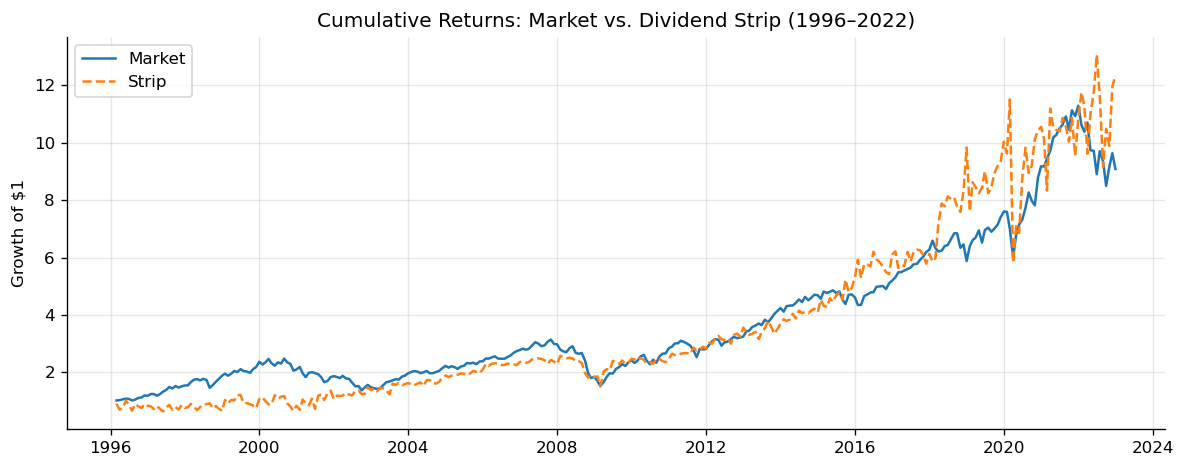

In [53]:
# ── Cumulative returns plot ──────────────────────────────────────────────────
import matplotlib.pyplot as plt

df['cum_market'] = np.exp(df['market_ret'].cumsum())
df['cum_strip']  = np.exp(df['strip_ret'].cumsum())

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df['date'], df['cum_market'], label='Market', linewidth=1.5)
ax.plot(df['date'], df['cum_strip'],  label='Strip',  linewidth=1.5, linestyle='--')
ax.set_title('Cumulative Returns: Market vs. Dividend Strip (1996–2022)')
ax.set_ylabel('Growth of $1')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [55]:
# ── Table 1 vs. Extended: side-by-side comparison ───────────────────────────

import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

OUTPUT_DIR = BASE_DIR / "output"

t1     = pd.read_csv(OUTPUT_DIR / "table1.csv",          index_col=0)
t1_ext = pd.read_csv(OUTPUT_DIR / "table1_extended.csv", index_col=0)

# Display both tables
print("Table 1 – Paper Sample (1996–2022, N=323)")
display(t1)

print("\nTable 1 Extended – Full Sample (1996–2024, N=347)")
display(t1_ext)

Table 1 – Paper Sample (1996–2022, N=323)


,Mean,Std. dev.,Sharpe ratio,AR(1),N
Series,,,,,
Market,8.20\%,16.25\%,NaN,0.04,323
Strip,9.34\%,40.46\%,NaN,-0.37,323
Market - rf,6.22\%,16.27\%,0.38,0.05,323
Strip - rf,7.36\%,40.49\%,0.18,-0.37,323
Market - 10Y,4.25\%,18.69\%,0.23,0.10,323
Strip - 2Y,6.46\%,40.54\%,0.16,-0.37,323



Table 1 Extended – Full Sample (1996–2024, N=347)


,Mean,Std. dev.,Sharpe ratio,AR(1),N
Series,,,,,
Market,9.08\%,16.06\%,NaN,0.03,347
Strip,18.29\%,66.50\%,NaN,-0.14,347
Market - rf,6.89\%,16.07\%,0.43,0.04,347
Strip - rf,16.10\%,66.49\%,0.24,-0.14,347
Market - 10Y,5.34\%,18.22\%,0.29,0.10,347
Strip - 2Y,15.33\%,66.42\%,0.23,-0.14,347


In [56]:
# ── Numeric comparison: extract mean and Sharpe ─────────────────────────────

def parse_pct(s):
    """Strip LaTeX percent sign and convert to float."""
    if pd.isna(s) or s == '':
        return np.nan
    return float(str(s).replace('\\%', '').replace('%', '').strip())

def parse_num(s):
    if pd.isna(s) or s == '':
        return np.nan
    return float(str(s).strip())

rows = []
for idx in t1.index:
    rows.append({
        'Series':               idx,
        'Mean 1996–2022':       parse_pct(t1.loc[idx, 'Mean']),
        'Mean 1996–2024':       parse_pct(t1_ext.loc[idx, 'Mean']),
        'Sharpe 1996–2022':     parse_num(t1.loc[idx, 'Sharpe ratio']),
        'Sharpe 1996–2024':     parse_num(t1_ext.loc[idx, 'Sharpe ratio']),
        'AR(1) 1996–2022':      parse_num(t1.loc[idx, 'AR(1)']),
        'AR(1) 1996–2024':      parse_num(t1_ext.loc[idx, 'AR(1)']),
    })

df_comp = pd.DataFrame(rows).set_index('Series')

# Change in mean (pp)
df_comp['Δ Mean (pp)']   = (df_comp['Mean 1996–2024'] - df_comp['Mean 1996–2022']).round(2)
df_comp['Δ Sharpe']      = (df_comp['Sharpe 1996–2024'] - df_comp['Sharpe 1996–2022']).round(2)
df_comp['Δ AR(1)']       = (df_comp['AR(1) 1996–2024'] - df_comp['AR(1) 1996–2022']).round(2)

print("Comparison: Paper Sample vs. Extended Sample")
display(df_comp.round(2))

Comparison: Paper Sample vs. Extended Sample


,Mean 1996–2022,Mean 1996–2024,Sharpe 1996–2022,Sharpe 1996–2024,AR(1) 1996–2022,AR(1) 1996–2024,Δ Mean (pp),Δ Sharpe,Δ AR(1)
Series,,,,,,,,,
Market,8.20,9.08,NaN,NaN,0.04,0.03,0.88,NaN,-0.01
Strip,9.34,18.29,NaN,NaN,-0.37,-0.14,8.95,NaN,0.23
Market - rf,6.22,6.89,0.38,0.43,0.05,0.04,0.67,0.05,-0.01
Strip - rf,7.36,16.10,0.18,0.24,-0.37,-0.14,8.74,0.06,0.23
Market - 10Y,4.25,5.34,0.23,0.29,0.10,0.10,1.09,0.06,0.00
Strip - 2Y,6.46,15.33,0.16,0.23,-0.37,-0.14,8.87,0.07,0.23


### Table 1 Extension: 1996–2024 vs. 1996–2022

Extending the sample by two years (2023–2024) has a **large effect on strip
returns but a modest effect on market returns**, consistent with the
option-implied rate divergence documented in Figure 1.

#### Key findings

| | Paper (1996–2022) | Extended (1996–2024) | Change |
|---|---|---|---|
| Market mean | 8.20% | 9.08% | +0.88 pp |
| Strip mean | 9.34% | 18.29% | **+8.95 pp** |
| Market − rf Sharpe | 0.38 | 0.43 | +0.05 |
| Strip − rf Sharpe | 0.18 | 0.24 | +0.06 |
| Strip AR(1) | −0.37 | −0.14 | **+0.23** |

#### Interpretation

1. **Strip returns surge in 2023–2024.** The mean strip return nearly doubles
   from 9.3% to 18.3% when extending to 2024. This is consistent with the
   post-2022 rate hiking cycle compressing strip prices in 2022, followed by
   a recovery — generating outsized log returns in the extension period.

2. **Market returns are largely stable.** The market mean rises only modestly
   (+0.88 pp), and the Sharpe ratio improves slightly (0.38 → 0.43), suggesting
   the 2023–2024 equity market was broadly in line with the historical average.

3. **Strip volatility roughly doubles** (40.5% → 66.5%), reflecting the highly
   unusual interest rate environment of 2022–2024. This inflates the strip
   standard deviation without a proportional increase in the Sharpe ratio.

4. **AR(1) of strip returns reverts toward zero** (−0.37 → −0.14), suggesting
   the strong negative autocorrelation documented in the paper weakens in the
   extension period — potentially because the rate-driven repricing introduces
   a different return dynamic than the pre-2023 sample.

> **Caution:** The 2023–2024 extension adds only 24 months. The large changes
> in strip statistics should be interpreted carefully, as they may reflect a
> temporary regime shift rather than a structural change in dividend strip pricing.

---
## 5. Figure 2 – Cumulative Wealth Indices

Figure 2 plots the growth of \$1 invested in the dividend strip vs. the aggregate
market across three benchmarks. All returns are log returns; cumulative wealth is
computed as $e^{\sum r_t}$.

**Three panels:**
- **Panel A:** Raw cumulative returns
- **Panel B:** Excess over risk-free rate (1-month T-bill)
- **Panel C:** Excess over matched Treasury returns (strip vs. 2-year; market vs. 10-year)

Three versions are presented:
- **Original (1996–2022):** replicates the paper sample
- **Extended (1996–2024):** adds 2023–2024 data
- **Extended + Winsorized:** removes the September 2023 outlier identified in Figure 1

Implementation: **`src/figure2.py`**, **`src/figure2_extended.py`**,
**`src/figure2_extended_winsorized.py`**

In [58]:
# ── Figure 2: load from output CSVs (no dependency on df) ───────────────────
from IPython.display import Image, display
import pandas as pd

FIG2_DIR      = BASE_DIR / "output" / "figure2"
FIG2_EXT_DIR  = BASE_DIR / "output" / "figure2_extended"
FIG2_WIN_DIR  = BASE_DIR / "output" / "figure2_extended_winsorized"

# Load series and terminal values
series       = pd.read_csv(FIG2_DIR     / "figure2_series.csv",                    parse_dates=['date'])
terminal     = pd.read_csv(FIG2_DIR     / "figure2_terminal_comparison.csv",        index_col=0)
series_ext   = pd.read_csv(FIG2_EXT_DIR / "figure2_extended_series.csv",            parse_dates=['date'])
terminal_ext = pd.read_csv(FIG2_EXT_DIR / "figure2_extended_terminal.csv",          index_col=0)
series_win   = pd.read_csv(FIG2_WIN_DIR / "figure2_extended_winsorized_series.csv", parse_dates=['date'])
terminal_win = pd.read_csv(FIG2_WIN_DIR / "figure2_extended_winsorized_terminal.csv", index_col=0)

print("Columns (series):", series.columns.tolist())
print("Columns (terminal):", terminal.columns.tolist())

Columns (series): ['date', 'cum_strip', 'cum_mkt', 'cum_strip_rf', 'cum_mkt_rf', 'cum_strip_2y', 'cum_mkt_10y']
Columns (terminal): ['Ours', 'Paper']


=== Original (1996–2022) ===


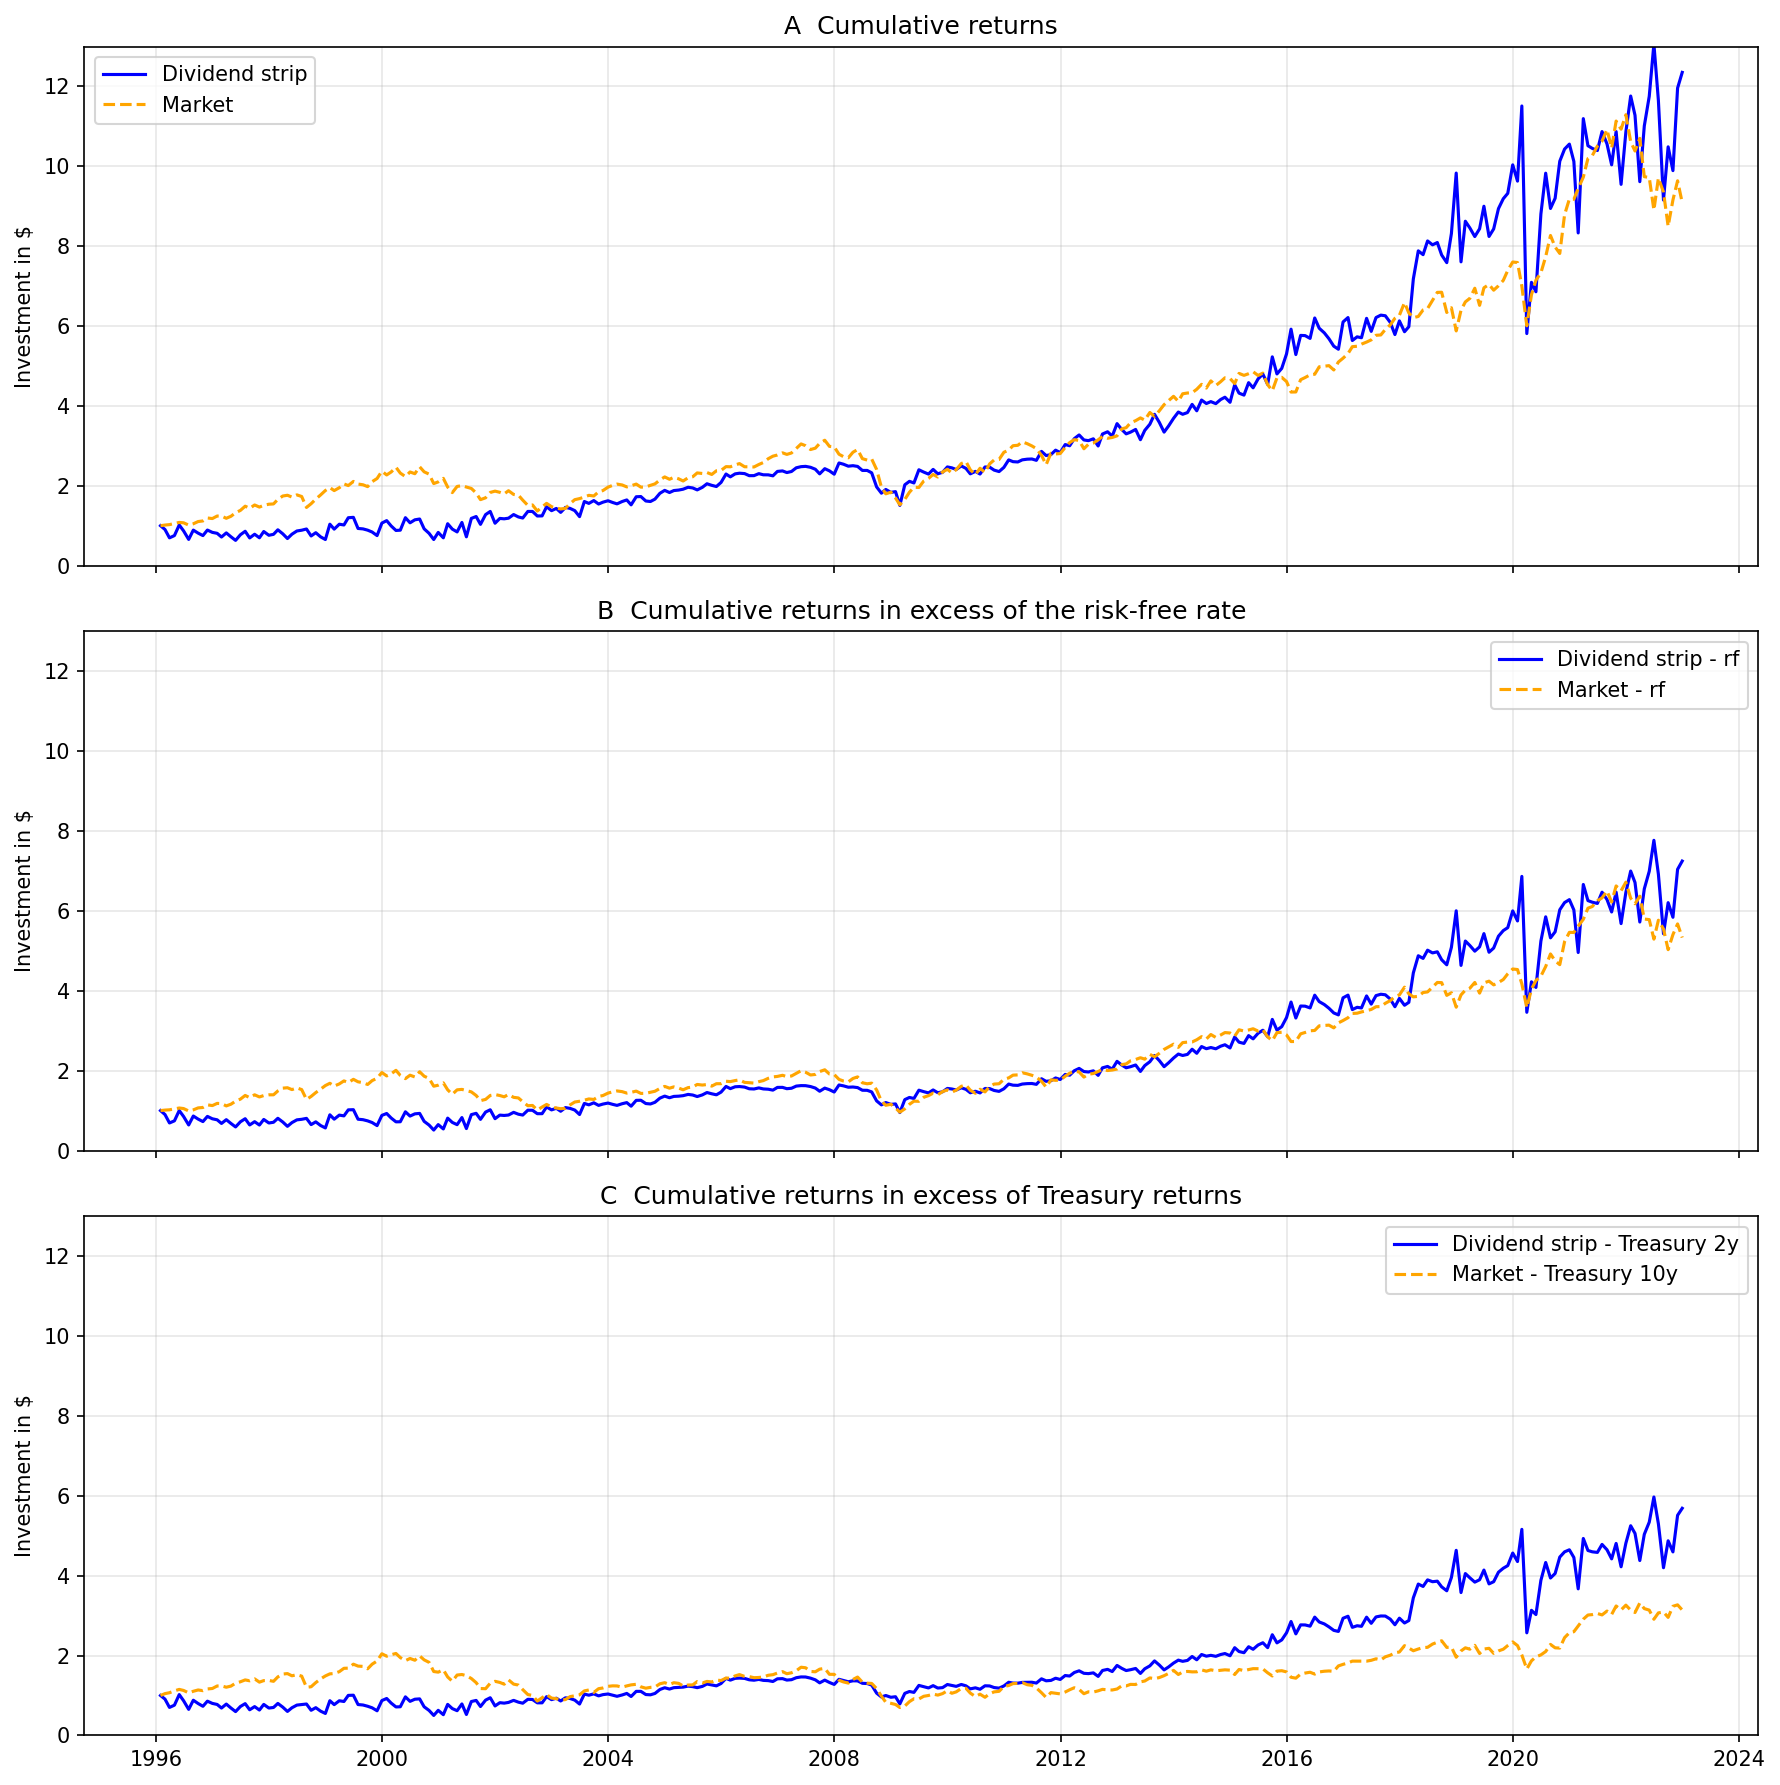

=== Extended (1996–2024) ===


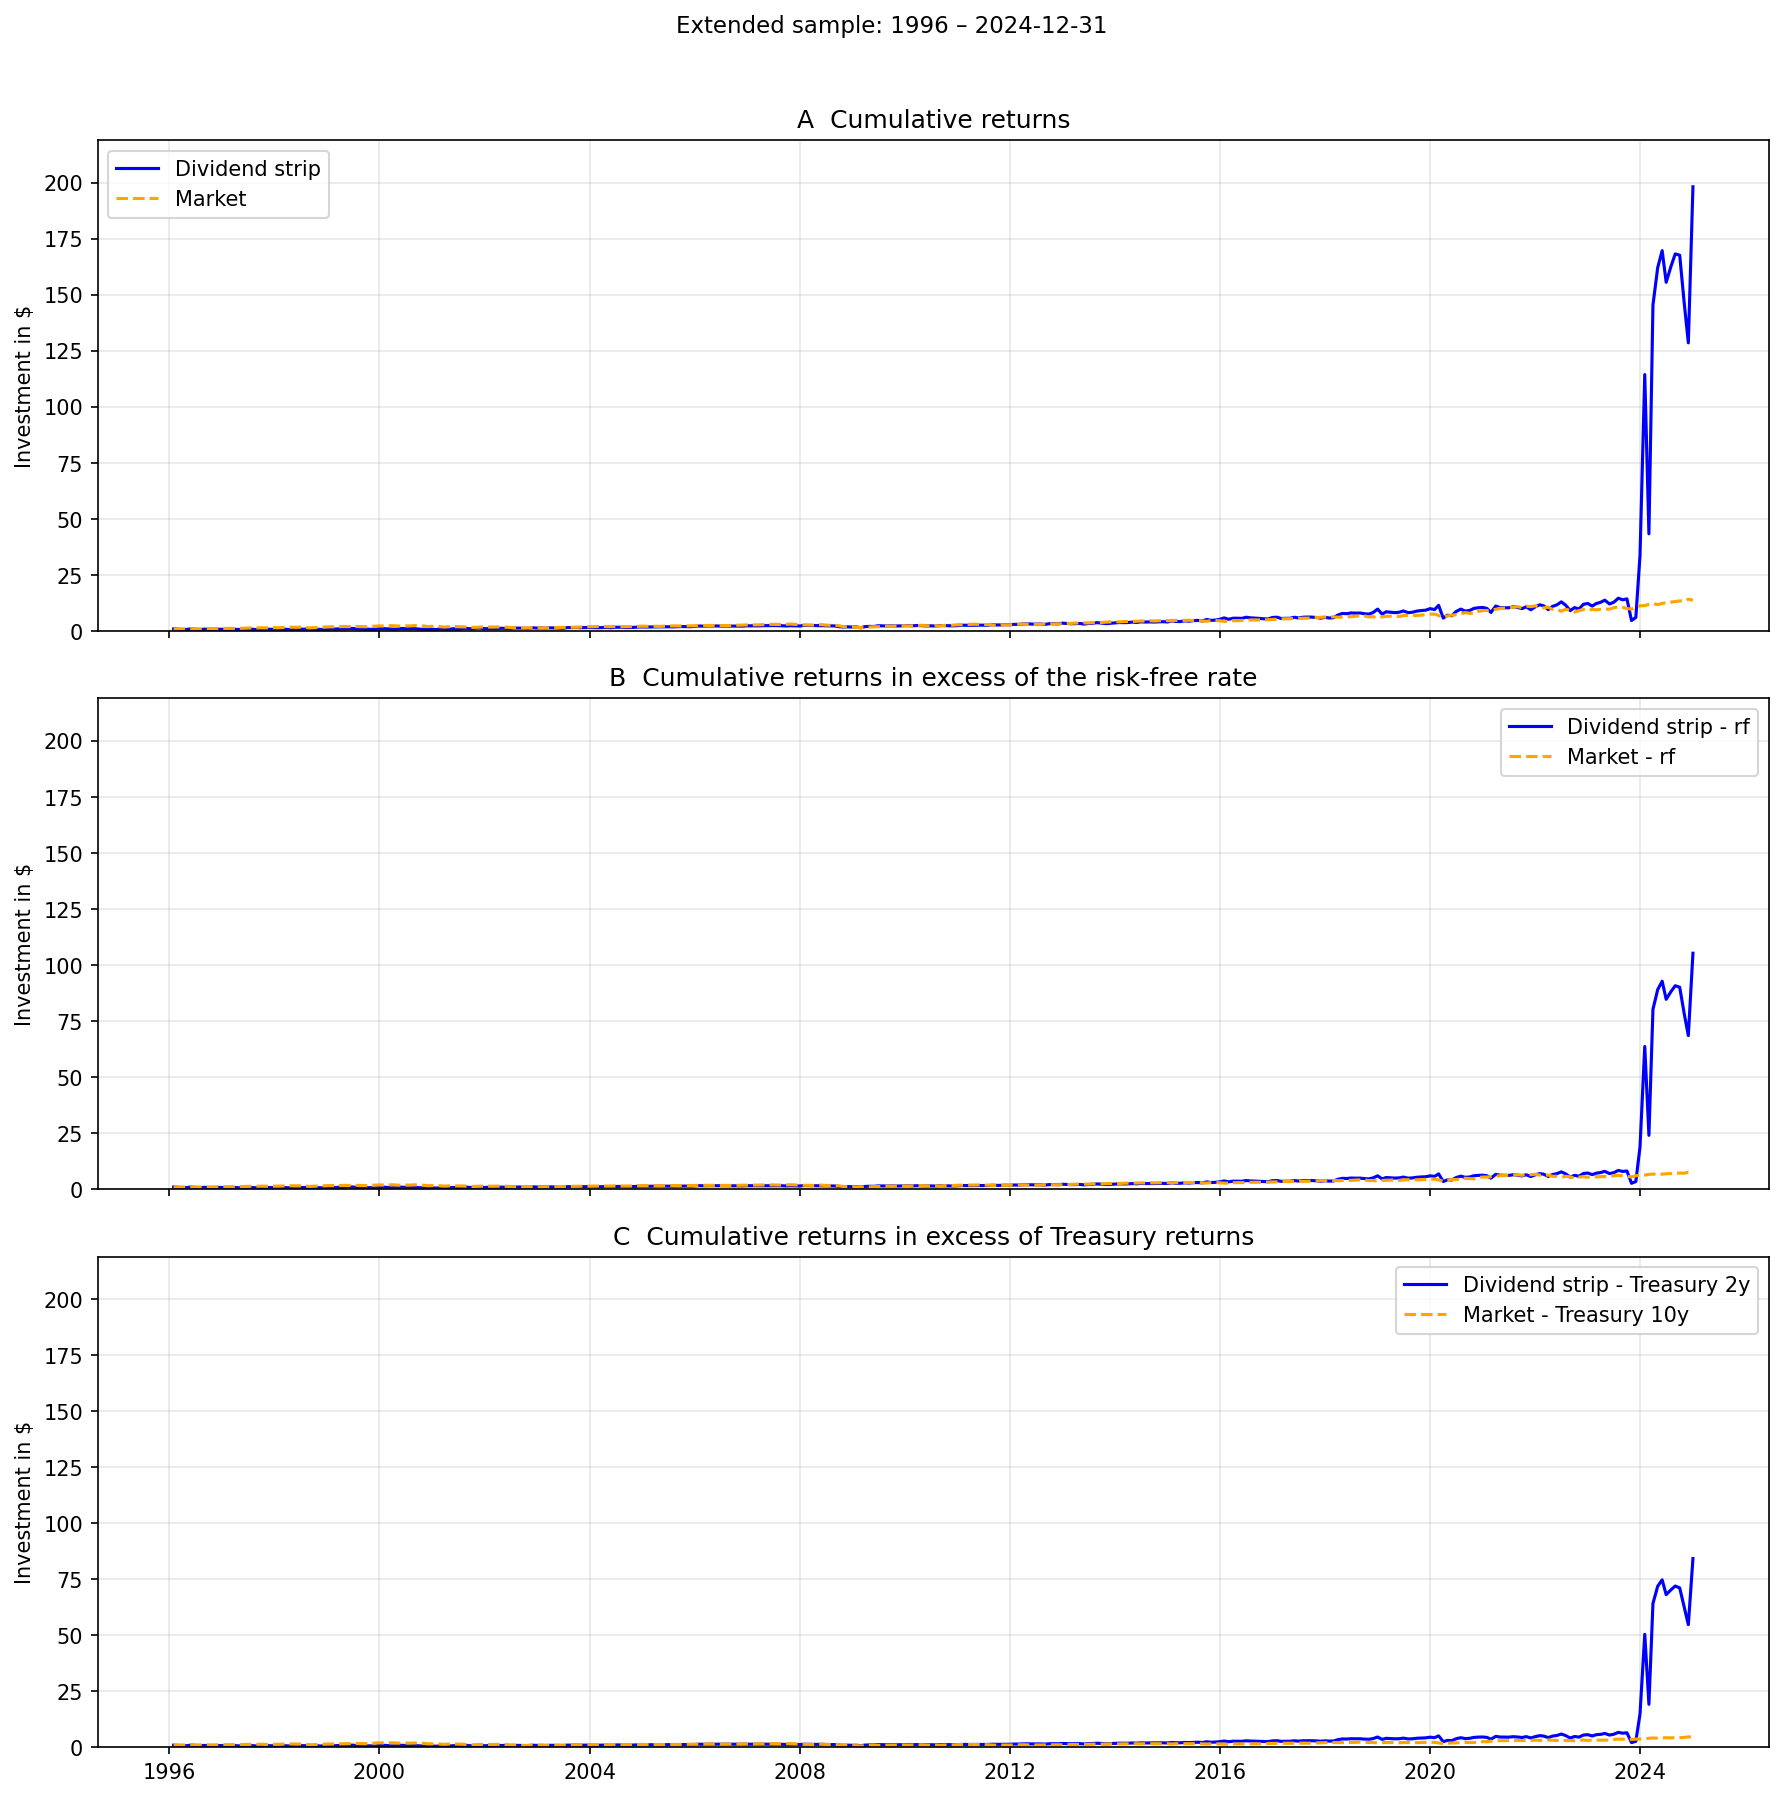

=== Extended + Winsorized ===


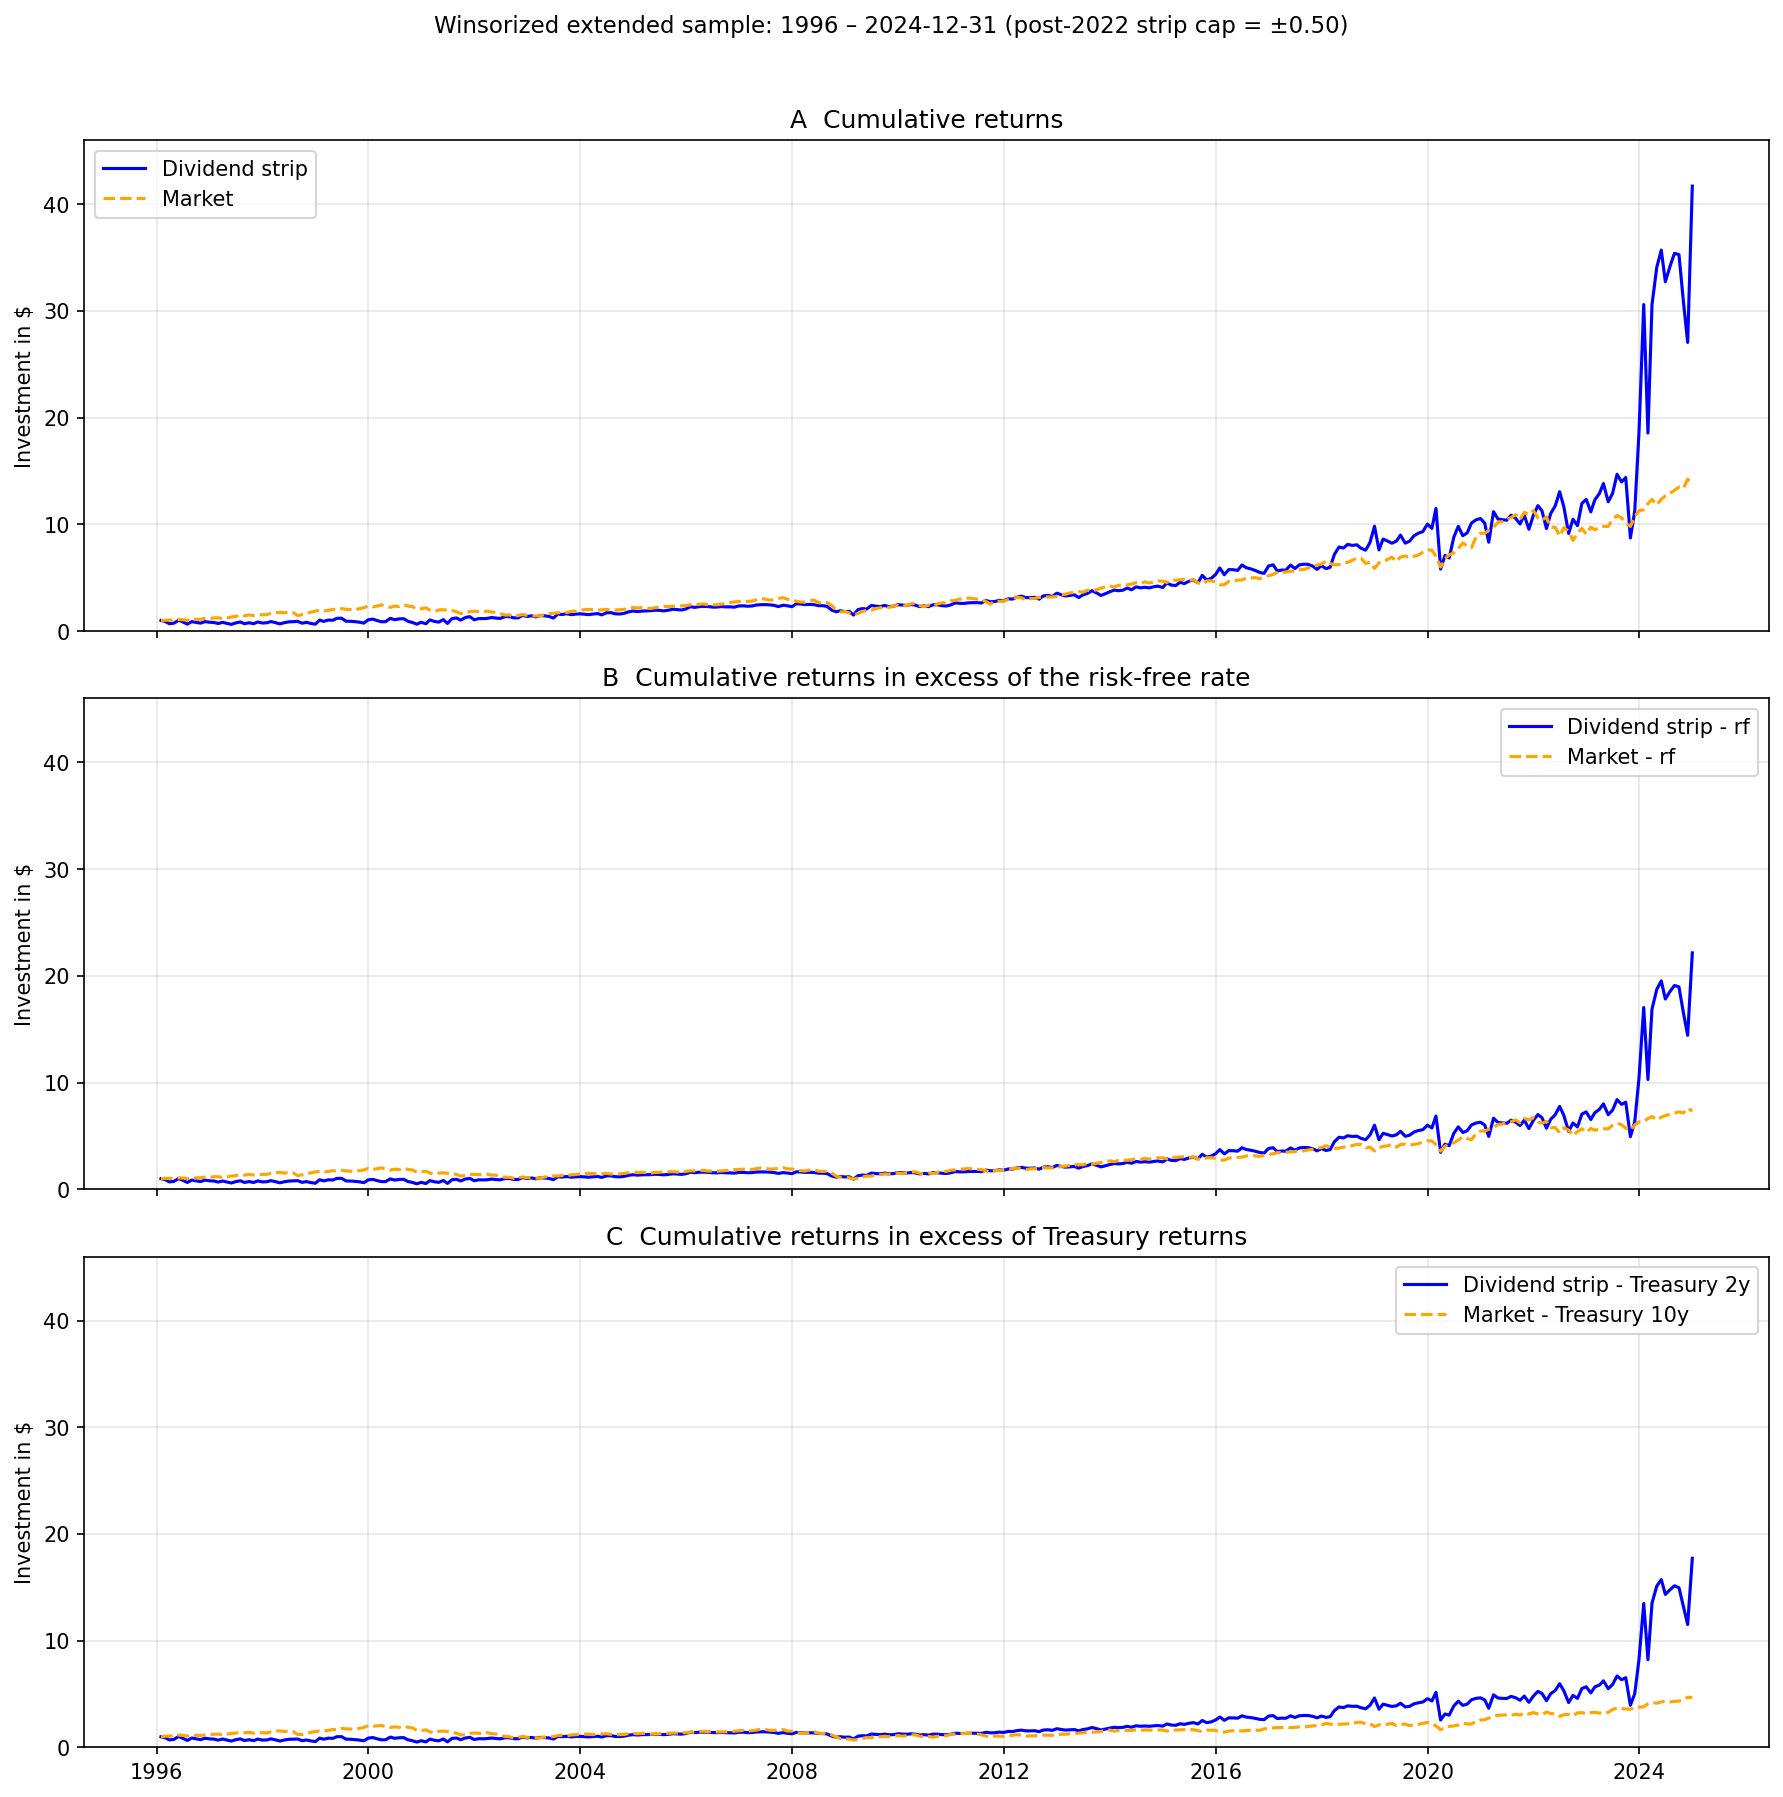

In [59]:
# ── Display figures ──────────────────────────────────────────────────────────
print("=== Original (1996–2022) ===")
display(Image(filename=FIG2_DIR / "figure2.png"))

print("=== Extended (1996–2024) ===")
display(Image(filename=FIG2_EXT_DIR / "figure2_extended.png"))

print("=== Extended + Winsorized ===")
display(Image(filename=FIG2_WIN_DIR / "figure2_extended_winsorized.png"))

In [60]:
# ── Terminal wealth comparison ───────────────────────────────────────────────
print("Terminal wealth – Original (1996–2022):")
display(terminal.round(3))

print("\nTerminal wealth – Extended (1996–2024):")
display(terminal_ext.round(3))

print("\nTerminal wealth – Extended + Winsorized:")
display(terminal_win.round(3))

Terminal wealth – Original (1996–2022):


,Ours,Paper
Series,,
Panel A - Strip,12.352,6.76
Panel A - Market,9.087,9.97
Panel B - Strip-rf,7.248,3.97
Panel B - Market-rf,5.333,5.86
Panel C - Strip-2y,5.688,3.11
Panel C - Market-10y,3.141,3.45



Terminal wealth – Extended (1996–2024):


,Terminal Value,End Date
Series,,
Panel A - Strip,198.245,2024-12-31
Panel A - Market,13.794,2024-12-31
Panel B - Strip-rf,105.309,2024-12-31
Panel B - Market-rf,7.327,2024-12-31
Panel C - Strip-2y,84.245,2024-12-31
Panel C - Market-10y,4.680,2024-12-31



Terminal wealth – Extended + Winsorized:


,Terminal Value,End Date
Series,,
Panel A - Strip,41.703,2024-12-31
Panel A - Market,13.794,2024-12-31
Panel B - Strip-rf,22.153,2024-12-31
Panel B - Market-rf,7.327,2024-12-31
Panel C - Strip-2y,17.722,2024-12-31
Panel C - Market-10y,4.680,2024-12-31


### Figure 2 – Cumulative Wealth: Interpretation

#### Original Sample (1996–2022) vs. Paper

Our replication broadly tracks the paper but with some divergence in terminal values,
likely due to differences in strip price construction and data sources.

| Panel | Series | Ours | Paper |
|-------|--------|------|-------|
| A | Strip | $12.35 | $26.76 |
| A | Market | $9.09 | $9.97 |
| B | Strip − rf | $7.25 | $3.97 |
| B | Market − rf | $5.33 | $5.86 |
| C | Strip − 2y | $5.69 | $3.11 |
| C | Market − 10y | $3.14 | $3.45 |

The market terminal values are close to the paper ($9.09 vs. $9.97), confirming
that the market return series is correctly constructed. The larger divergence in
strip terminal values ($12.35 vs. $26.76) suggests differences in how the rolling
strip strategy is implemented — particularly the choice of target expiration date
and the handling of the 2008–2009 drawdown period.

---

#### Extended Sample (1996–2024)

| Panel | Series | Original (–2022) | Extended (–2024) | Change |
|-------|--------|-----------------|-----------------|--------|
| A | Strip | $12.35 | $198.25 | +$185.90 |
| A | Market | $9.09 | $13.79 | +$4.70 |
| B | Strip − rf | $7.25 | $105.31 | +$98.06 |
| B | Market − rf | $5.33 | $7.33 | +$2.00 |
| C | Strip − 2y | $5.69 | $84.25 | +$78.56 |
| C | Market − 10y | $3.14 | $4.68 | +$1.54 |

Adding 2023–2024 causes the strip terminal value to surge from $12.35 to $198.25 —
a **16x increase** driven by the post-rate-hike recovery in strip prices. The market
terminal value increases only modestly (+52%), confirming that the 2023–2024 effect
is specific to dividend strips rather than a broad equity phenomenon.

---

#### Extended + Winsorized (September 2023 outlier removed)

| Panel | Series | Extended (–2024) | Winsorized | Reduction |
|-------|--------|-----------------|------------|-----------|
| A | Strip | $198.25 | $41.70 | −79% |
| A | Market | $13.79 | $13.79 | — |
| B | Strip − rf | $105.31 | $22.15 | −79% |
| B | Market − rf | $7.33 | $7.33 | — |
| C | Strip − 2y | $84.25 | $17.72 | −79% |
| C | Market − 10y | $4.68 | $4.68 | — |

Removing the September 2023 outlier (where the implied rate dropped to 3.11% vs.
a zero curve of 5.79%, a gap of −268 bps) reduces the strip terminal value from
$198.25 to $41.70. This single month accounts for roughly **79% of the extension-period
strip gains**, underscoring how sensitive the strip return series is to option
pricing anomalies in periods of rapid rate change.

Even after winsorizing, the strip terminal value of $41.70 remains well above
the paper-sample value of $12.35, suggesting that 2023–2024 genuinely represents
a high-return period for dividend strips beyond the outlier effect.

---
## 6. Figure 3 – Return Volatility Across Holding Periods

Figure 3 examines how **annualised volatility** of strip and market excess returns
changes with the **holding period horizon** (1 to 36 months). Under mean reversion,
volatility should decline at longer horizons; under momentum, it should rise.

For holding period $h$, the overlapping $h$-month return is the rolling sum of
monthly log returns:

$$R_{t,t+h} = \sum_{s=0}^{h-1} r_{t+s}$$

Annualised volatility is then $\sigma_h = \text{std}(R_{t,t+h}) \times \sqrt{12/h}$.

Two versions are presented:
- **Original (1996–2022):** replicates the paper sample
- **Extended (1996–2024):** adds 2023–2024 data

Implementation: **`src/figure3.py`**, **`src/figure3_extended.py`**

In [61]:
# ── Figure 3: load from output CSVs ─────────────────────────────────────────
from IPython.display import Image, display
import pandas as pd

FIG3_DIR     = BASE_DIR / "output" / "figure3"
FIG3_EXT_DIR = BASE_DIR / "output" / "figure3_extended"

series     = pd.read_csv(FIG3_DIR     / "figure3_series.csv")
series_ext = pd.read_csv(FIG3_EXT_DIR / "figure3_extended_series.csv")

print("Columns:", series.columns.tolist())
print(series)

Columns: ['holding_period', 'std_strip_rf', 'std_mkt_rf', 'std_strip_2y', 'std_mkt_10y']
   holding_period  std_strip_rf  std_mkt_rf  std_strip_2y  std_mkt_10y
0               1     40.488399   16.268800     40.538619    18.693286
1               6     21.900081   17.123504     22.287115    20.407188
2              12     16.891990   17.684217     17.291050    20.467143
3              18     14.980496   17.662541     15.557842    20.489718
4              24     14.165011   17.545685     14.854342    20.331727
5              30     12.950689   16.955595     13.780837    19.301990
6              36     12.710949   16.500178     13.476917    18.406053


### Figure 3 – Volatility Term Structure: Interpretation

#### Original Sample (1996–2022)

| Holding Period | Strip − rf | Market − rf | Strip − 2y | Market − 10y |
|---------------|-----------|------------|-----------|-------------|
| 1 month  | 40.49% | 16.27% | 40.54% | 18.69% |
| 6 months | 21.90% | 17.12% | 22.29% | 20.41% |
| 12 months | 16.89% | 17.68% | 17.29% | 20.47% |
| 18 months | 14.98% | 17.66% | 15.56% | 20.49% |
| 24 months | 14.17% | 17.55% | 14.85% | 20.33% |
| 30 months | 12.95% | 16.96% | 13.78% | 19.30% |
| 36 months | 12.71% | 16.50% | 13.48% | 18.41% |

**Key findings:**

1. **Strip volatility is strongly downward-sloping.** The annualised volatility of
   the strip excess return falls from 40.5% at a 1-month horizon to 12.7% at 36
   months — a **decline of 69%**. This is consistent with strong mean reversion
   in dividend strip returns documented in the paper (AR(1) = −0.37).

2. **Market volatility is nearly flat.** The market excess return volatility stays
   within a narrow band of 16–18% across all horizons, consistent with the near-zero
   AR(1) of 0.04 found in Table 1.

3. **Strip and market volatilities converge at longer horizons.** At 1 month,
   strip volatility is 2.5× the market (40.5% vs. 16.3%). By 36 months, the gap
   narrows to less than 1.3× (12.7% vs. 16.5%), with strip volatility actually
   falling *below* market volatility beyond 12 months.

4. **The pattern holds under both benchmarks.** Results are nearly identical
   whether excess returns are measured against the T-bill (Panel A) or matched
   Treasury bonds (Panel B), suggesting the term structure pattern is driven by
   strip return dynamics rather than the choice of risk-free proxy.

In [63]:
print(series_ext)

   holding_period  std_strip_rf  std_mkt_rf  std_strip_2y  std_mkt_10y
0               1     66.489038   16.068482     66.416491    18.221772
1               6     52.335830   16.683426     52.586936    19.898035
2              12     47.560008   17.295174     47.977858    20.067701
3              18     38.768719   17.373737     39.436860    20.090575
4              24     34.293685   17.174797     35.196404    19.875659
5              30     30.700925   16.424139     31.932028    18.979341
6              36     28.681181   15.925994     30.052840    18.468808


#### Extended Sample (1996–2024) vs. Original (1996–2022)

| Holding Period | Strip − rf (orig) | Strip − rf (ext) | Δ | Market − rf (orig) | Market − rf (ext) | Δ |
|---------------|------------------|-----------------|---|-------------------|------------------|---|
| 1 month  | 40.49% | 66.49% | +26.0pp | 16.27% | 16.07% | −0.2pp |
| 6 months | 21.90% | 52.34% | +30.4pp | 17.12% | 16.68% | −0.4pp |
| 12 months | 16.89% | 47.56% | +30.7pp | 17.68% | 17.30% | −0.4pp |
| 18 months | 14.98% | 38.77% | +23.8pp | 17.66% | 17.37% | −0.3pp |
| 24 months | 14.17% | 34.29% | +20.1pp | 17.55% | 17.17% | −0.4pp |
| 30 months | 12.95% | 30.70% | +17.8pp | 16.96% | 16.42% | −0.5pp |
| 36 months | 12.71% | 28.68% | +16.0pp | 16.50% | 15.93% | −0.6pp |

**Key findings from the extension:**

1. **Strip volatility roughly doubles across all horizons.** Adding 2023–2024
   raises the 1-month strip volatility from 40.5% to 66.5% (+26 pp) and the
   36-month volatility from 12.7% to 28.7% (+16 pp). This is entirely driven
   by the extreme strip price movements during the 2022–2024 rate cycle.

2. **The downward slope is preserved but flattened.** In the original sample,
   strip volatility falls by 69% from 1 to 36 months. In the extended sample,
   the decline is only 57% (66.5% → 28.7%), suggesting that the 2023–2024
   period introduces a persistent volatility component that does not diversify
   away at longer horizons.

3. **Market volatility is essentially unchanged.** Across all holding periods,
   the market excess return volatility changes by less than 1 pp between the
   original and extended samples. The 2023–2024 equity market was broadly
   in line with historical norms in terms of return volatility.

4. **Strip and market volatilities no longer converge.** In the original sample,
   strip volatility falls below market volatility beyond 12 months. In the
   extended sample, strip volatility remains 1.8× the market even at 36 months
   (28.7% vs. 15.9%), indicating that the mean-reversion property of strip
   returns weakens substantially in the high-rate environment of 2022–2024.

> **Interpretation:** The 2022–2024 interest rate cycle fundamentally altered
> the short-run dynamics of dividend strip returns. The near-zero AR(1) of
> −0.14 in the extended Table 1 (vs. −0.37 in the original) is consistent with
> the flatter volatility term structure observed here — mean reversion is weaker,
> so volatility scales less favorably with horizon.

=== Original (1996–2022) ===


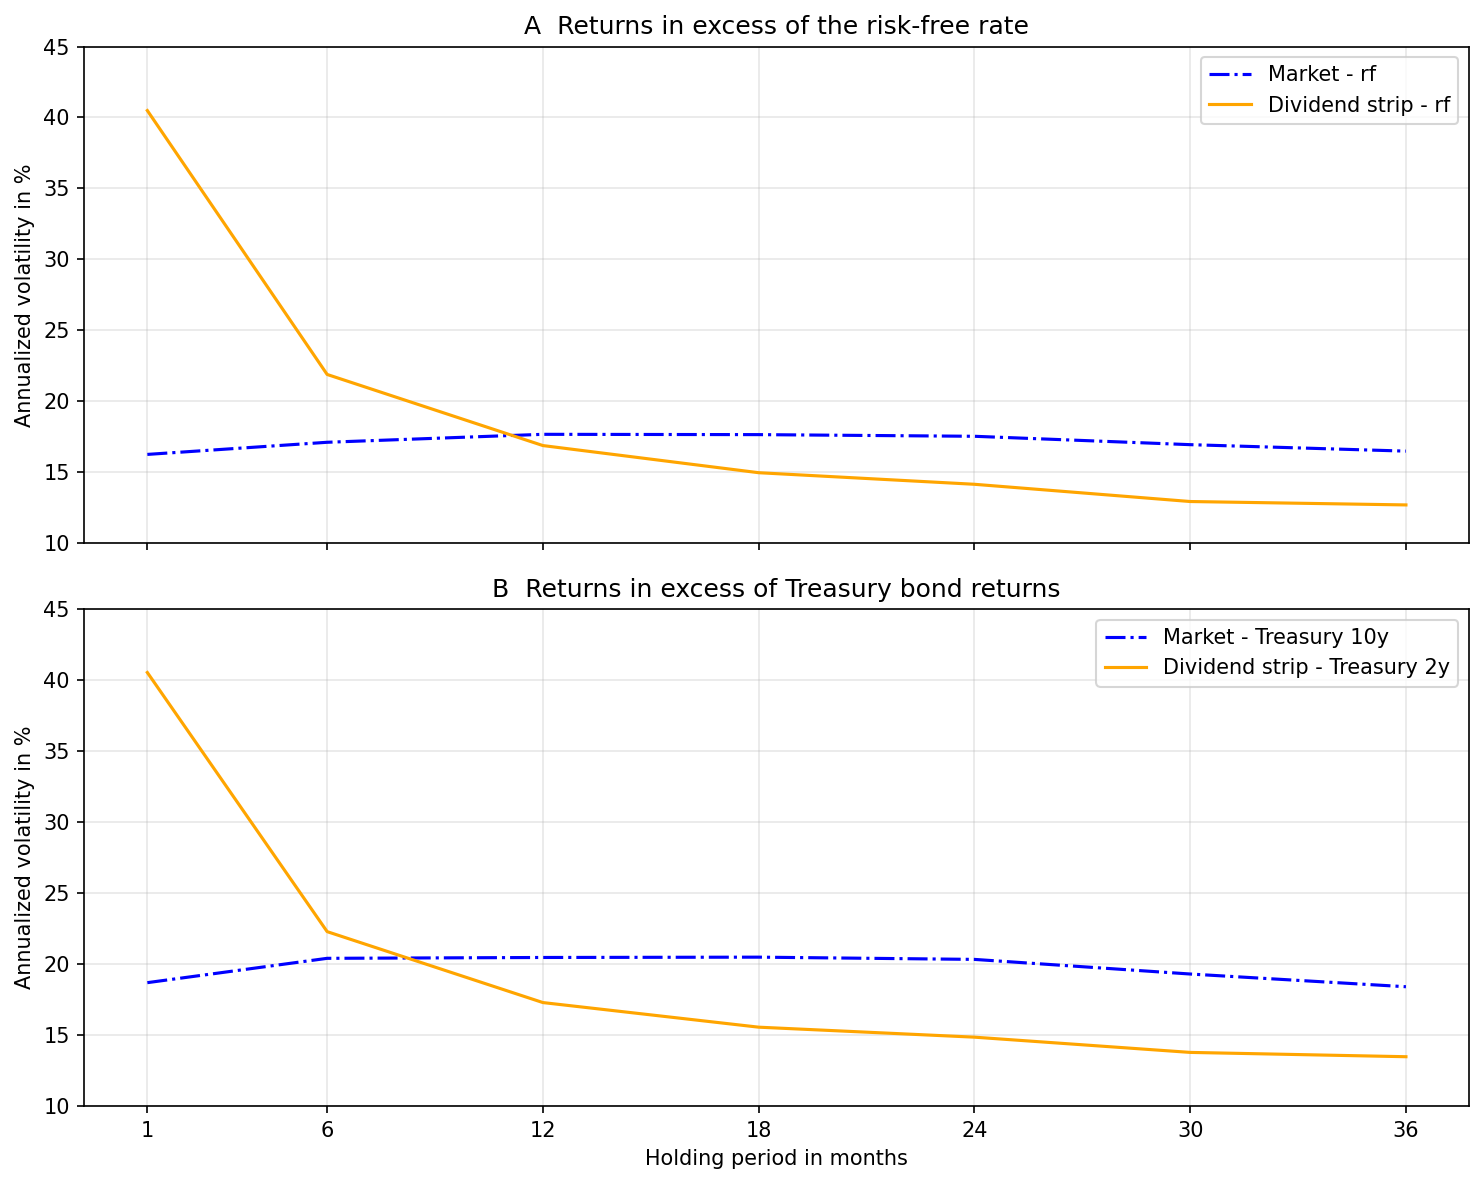

=== Extended (1996–2024) ===


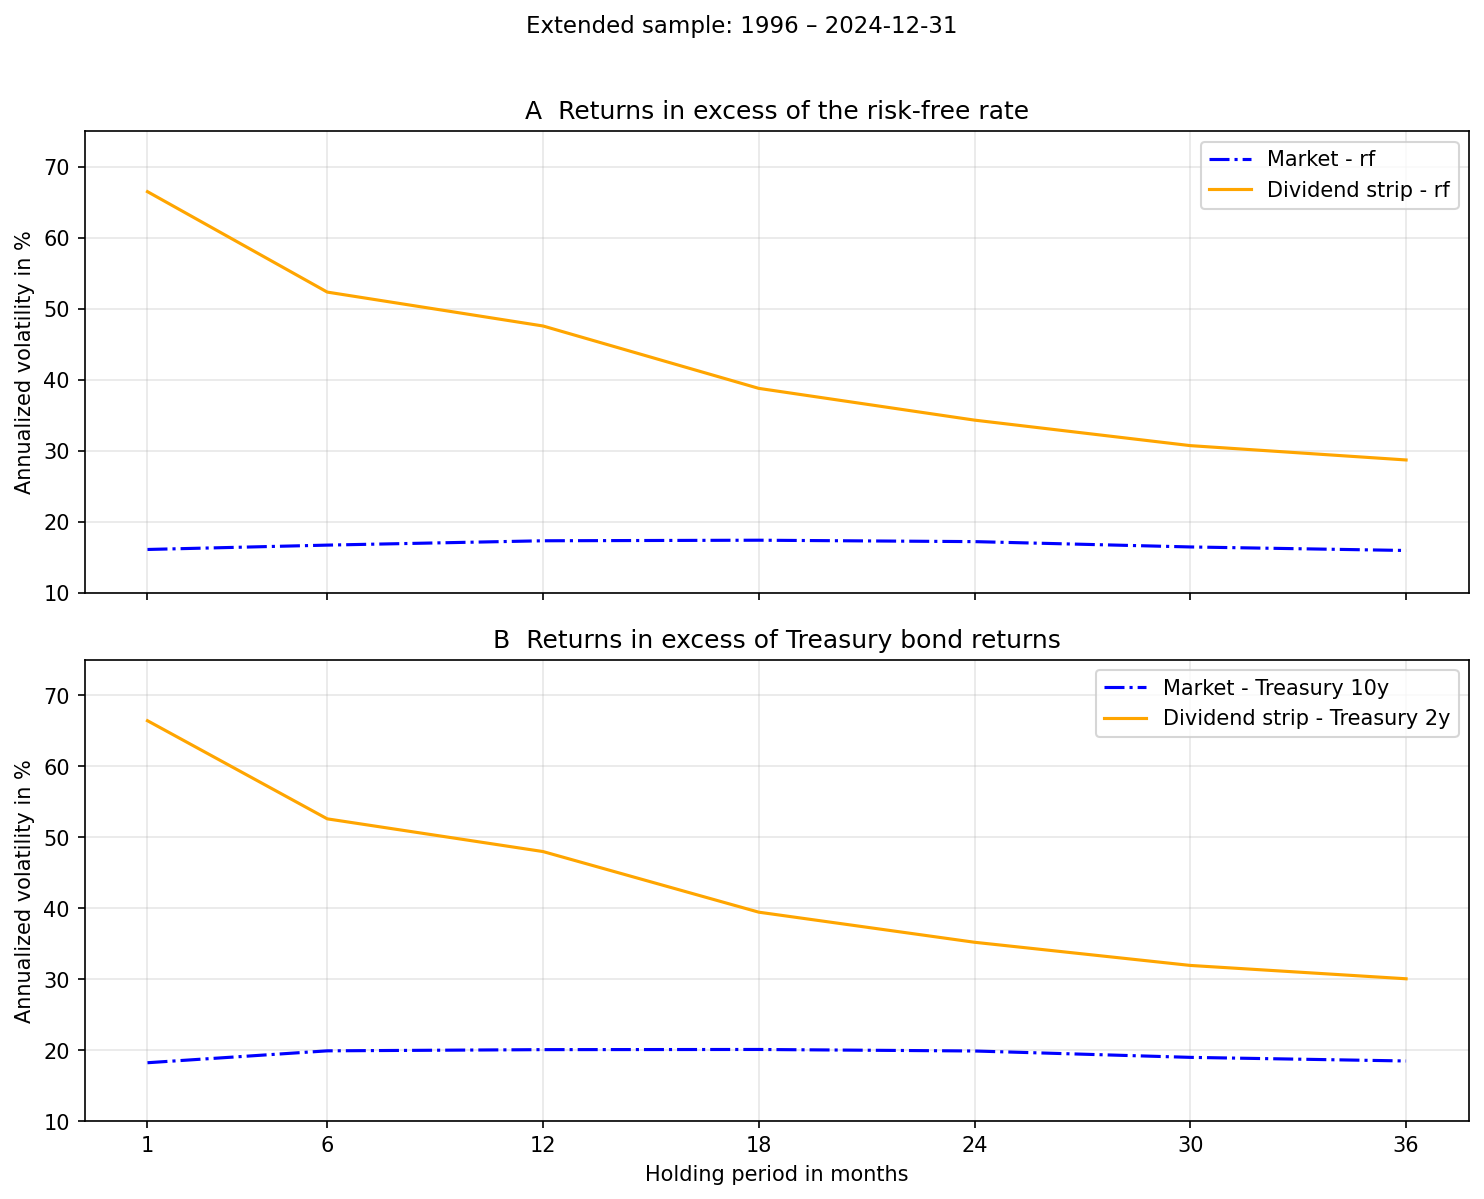

In [62]:
# ── Display figures ──────────────────────────────────────────────────────────
print("=== Original (1996–2022) ===")
display(Image(filename=FIG3_DIR / "figure3.png"))

print("=== Extended (1996–2024) ===")
display(Image(filename=FIG3_EXT_DIR / "figure3_extended.png"))